# Feedforward Neural Network (FFNN) Testing

13522029
13522043
13522093

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm.notebook import tqdm
from sklearn.neural_network import MLPClassifier

sys.path.append(os.path.abspath('..'))

from src.models.ffnn import FFNN
from src.models.activations import get_activation
from src.models.losses import get_loss
from src.models.initializers import get_initializer
from src.models.utils import (
    plot_training_history, plot_weight_distribution, 
    plot_network_graph, one_hot_encode, batch_iterator
)


Load dataset

In [2]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, parser='auto')

# ensure correct data types
X = X.to_numpy().astype(np.float32)
y = y.to_numpy().astype(np.int32)

# Normalize pixel values to [0, 1]
X = X / 255.0

print(f"MNIST dataset loaded:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of classes: {len(np.unique(y))}")

MNIST dataset loaded:
X shape: (70000, 784)
y shape: (70000,)
Number of classes: 10


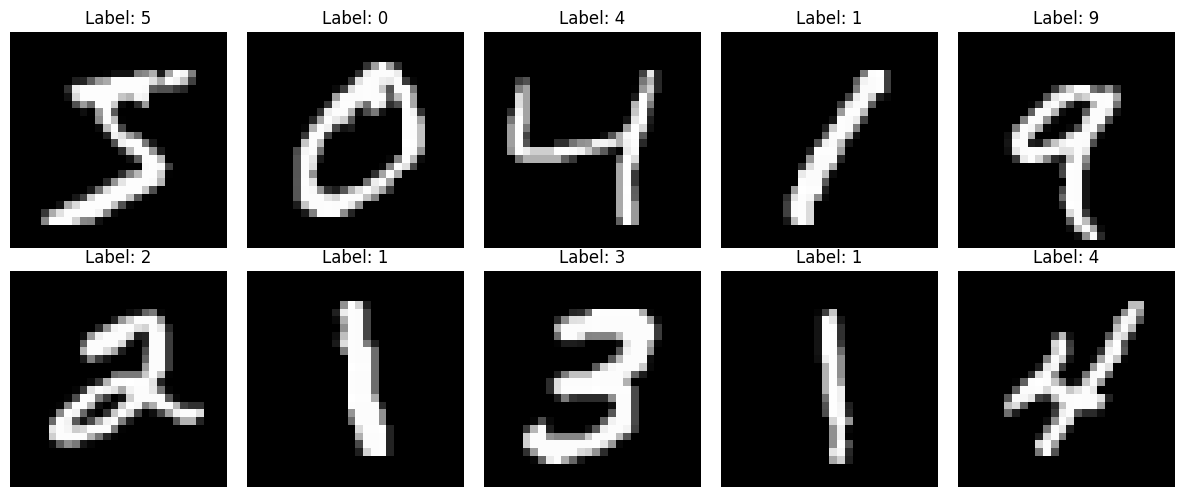

In [3]:
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [4]:
n_samples = 50000  # Berapa data
X_subset = X[:n_samples]
y_subset = y[:n_samples]

X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.2, random_state=42
)

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# one hot encode multiclass class
y_train_one_hot = one_hot_encode(y_train)
y_test_one_hot = one_hot_encode(y_test)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
# print(f"One-hot encoded labels shape: {y_train_one_hot.shape}")

Training data shape: (40000, 784)
Testing data shape: (10000, 784)


In [5]:
def plot_comparison(histories, title="Model Comparison", metric="train_loss"):
    plt.figure(figsize=(12, 5))
    
    for name, history in histories.items():
        if metric in history and history[metric] is not None:
            plt.plot(history[metric], label=name)
    
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss" if "loss" in metric else "Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def evaluate_model(model, X_test, y_test, y_test_one_hot):
    y_pred = model.predict(X_test)
    
    if model.activations[-1].name() == "Softmax":
        y_pred_class = np.argmax(y_pred, axis=1)
    else:
        y_pred_class = np.round(y_pred).astype(int)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred_class)
    print(f"Test accuracy: {accuracy:.4f}")
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred_class)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix (Accuracy: {accuracy:.4f})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    
    return accuracy

## Depth and Width Experiments

In [6]:
# Parameter eksperimen
learning_rate = 0.01
batch_size = 64
epochs = 20  # increase / decrease sesuaikan (sekarang 20 utk eksperimen)

models = {}
histories = {}


--- Width Experiments ---

Training model with width=64


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 280.45it/s]


Epoch 1/20 - 2.28s - loss: 2.4000 - val_loss: 2.3619 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 291.09it/s]


Epoch 2/20 - 2.19s - loss: 2.3114 - val_loss: 2.2855 - lr: 0.010000


...

Epoch 18/20 - 2.21s - loss: 1.3484 - val_loss: 1.3396 - lr: 0.010000


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 285.91it/s]


Epoch 19/20 - 2.23s - loss: 1.2959 - val_loss: 1.2887 - lr: 0.010000


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 290.97it/s]


Epoch 20/20 - 2.20s - loss: 1.2454 - val_loss: 1.2398 - lr: 0.010000

Evaluation for width_narrow:
Test accuracy: 0.6664


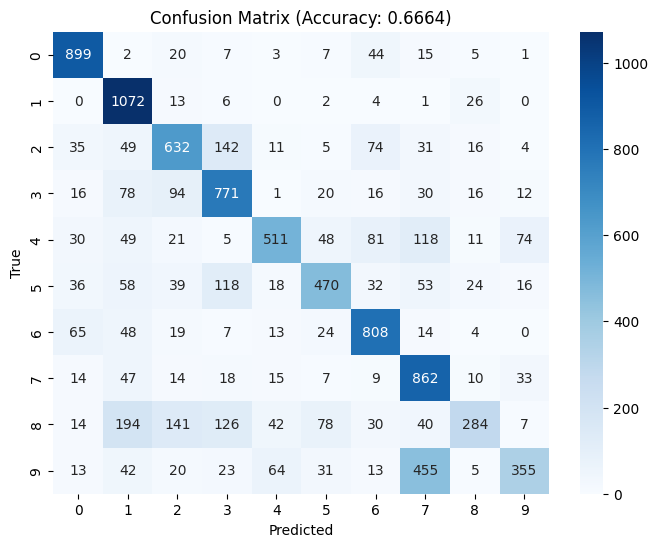


Weight distribution for width_narrow:


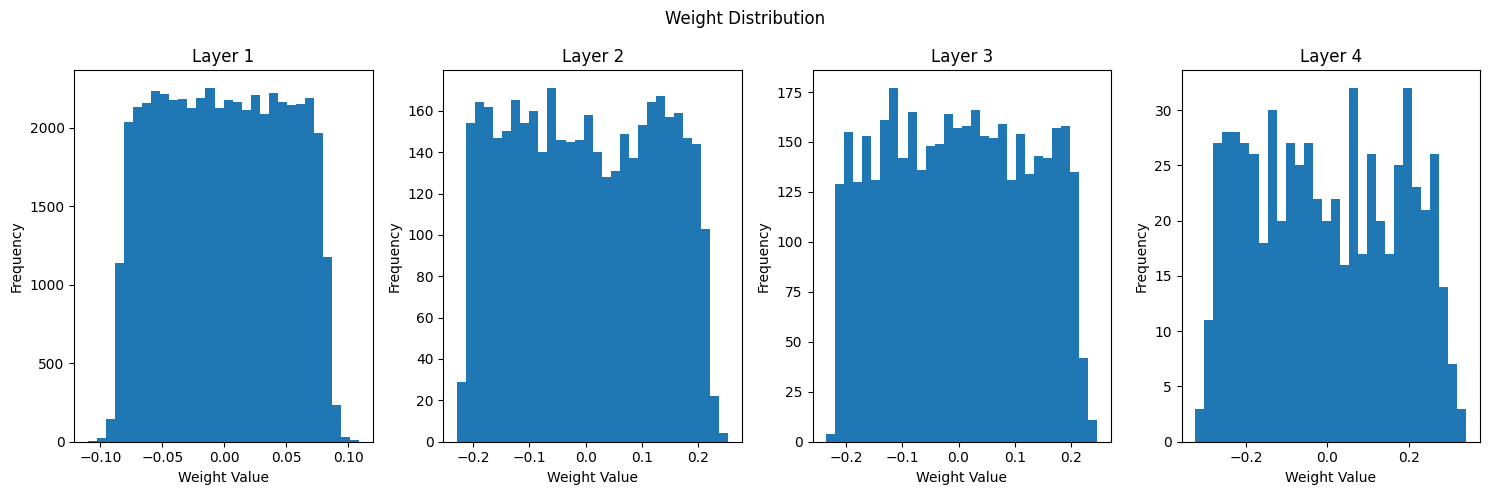


Gradient distribution for width_narrow:


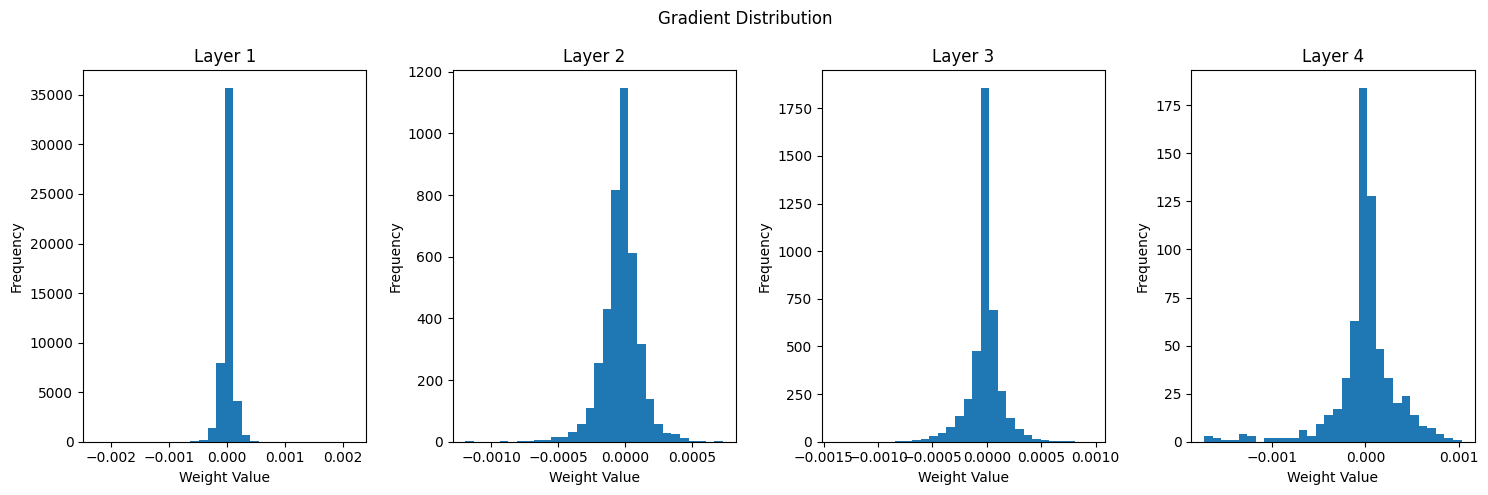


Training model with width=128


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 214.26it/s]


Epoch 1/20 - 3.00s - loss: 2.3574 - val_loss: 2.2995 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 221.40it/s]


Epoch 2/20 - 2.90s - loss: 2.2486 - val_loss: 2.2034 - lr: 0.010000


...

Epoch 18/20 - 2.84s - loss: 1.0677 - val_loss: 1.0553 - lr: 0.010000


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 227.27it/s]


Epoch 19/20 - 2.82s - loss: 1.0150 - val_loss: 1.0051 - lr: 0.010000


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 229.54it/s]


Epoch 20/20 - 2.79s - loss: 0.9663 - val_loss: 0.9588 - lr: 0.010000

Evaluation for width_medium:
Test accuracy: 0.7672


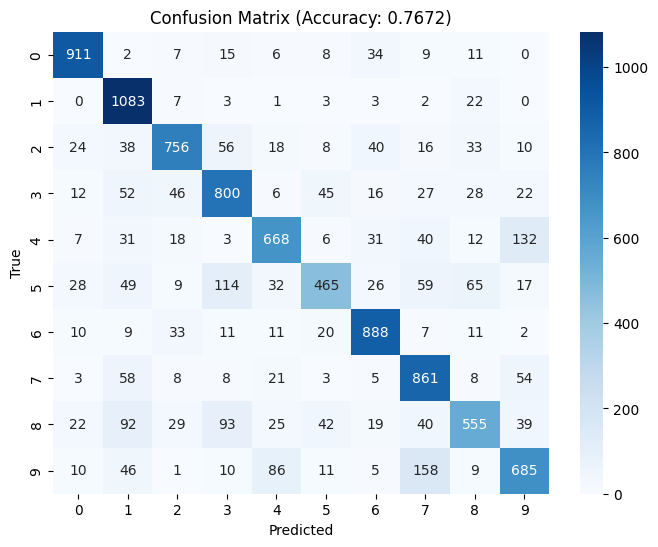


Weight distribution for width_medium:


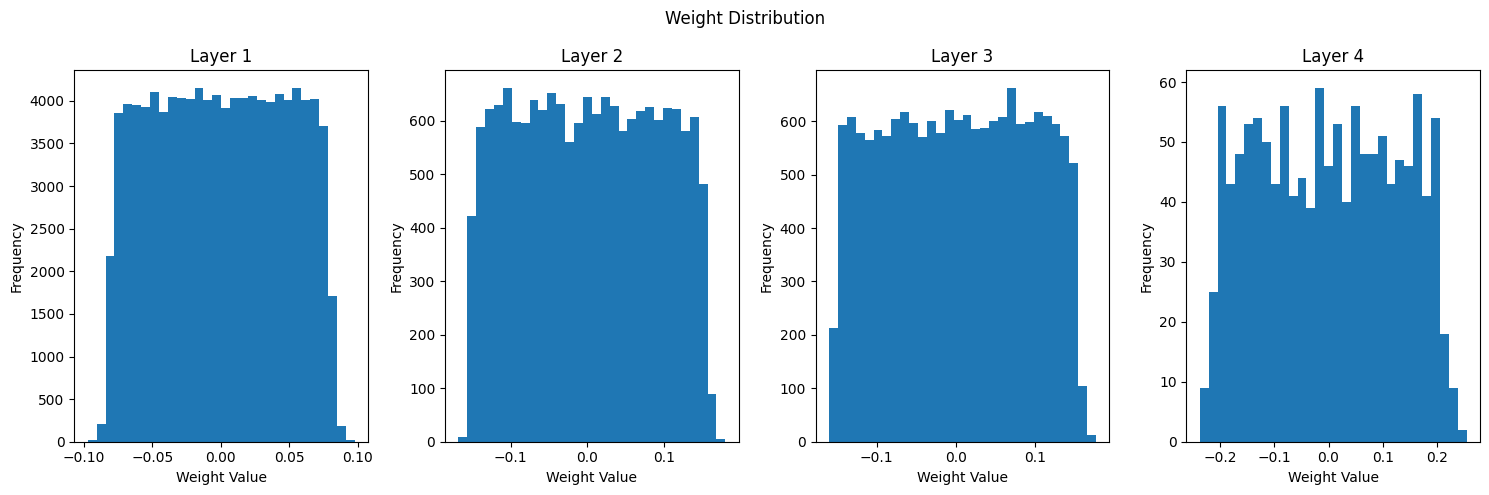


Gradient distribution for width_medium:


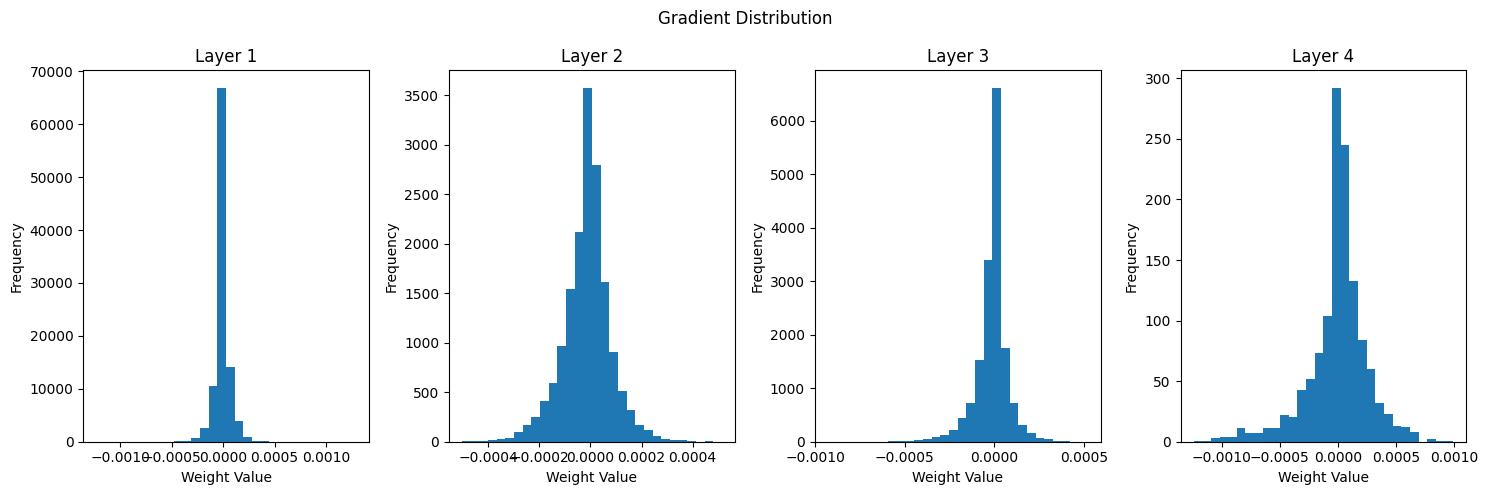


Training model with width=256


Epoch 1/20: 100%|██████████| 625/625 [00:04<00:00, 137.44it/s]


Epoch 1/20 - 4.67s - loss: 2.4064 - val_loss: 2.3359 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:04<00:00, 140.01it/s]


Epoch 2/20 - 4.59s - loss: 2.2597 - val_loss: 2.2077 - lr: 0.010000


...

Epoch 18/20 - 4.52s - loss: 0.8952 - val_loss: 0.8944 - lr: 0.010000


Epoch 19/20: 100%|██████████| 625/625 [00:04<00:00, 142.24it/s]


Epoch 19/20 - 4.53s - loss: 0.8513 - val_loss: 0.8532 - lr: 0.010000


Epoch 20/20: 100%|██████████| 625/625 [00:04<00:00, 139.17it/s]


Epoch 20/20 - 4.63s - loss: 0.8114 - val_loss: 0.8160 - lr: 0.010000

Evaluation for width_wide:
Test accuracy: 0.8096


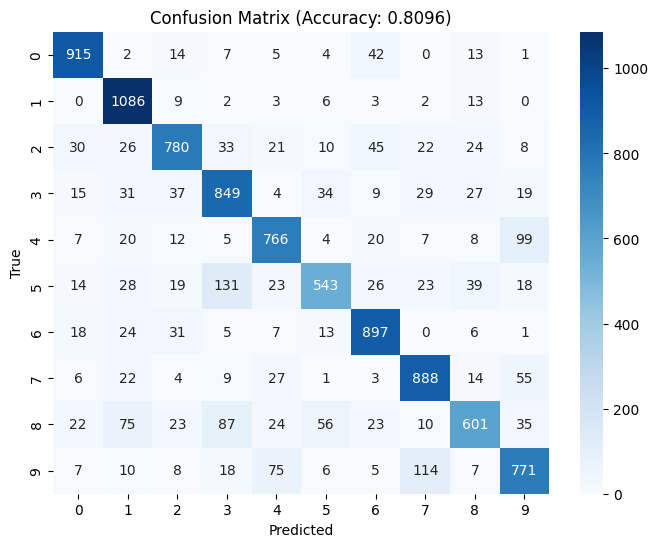


Weight distribution for width_wide:


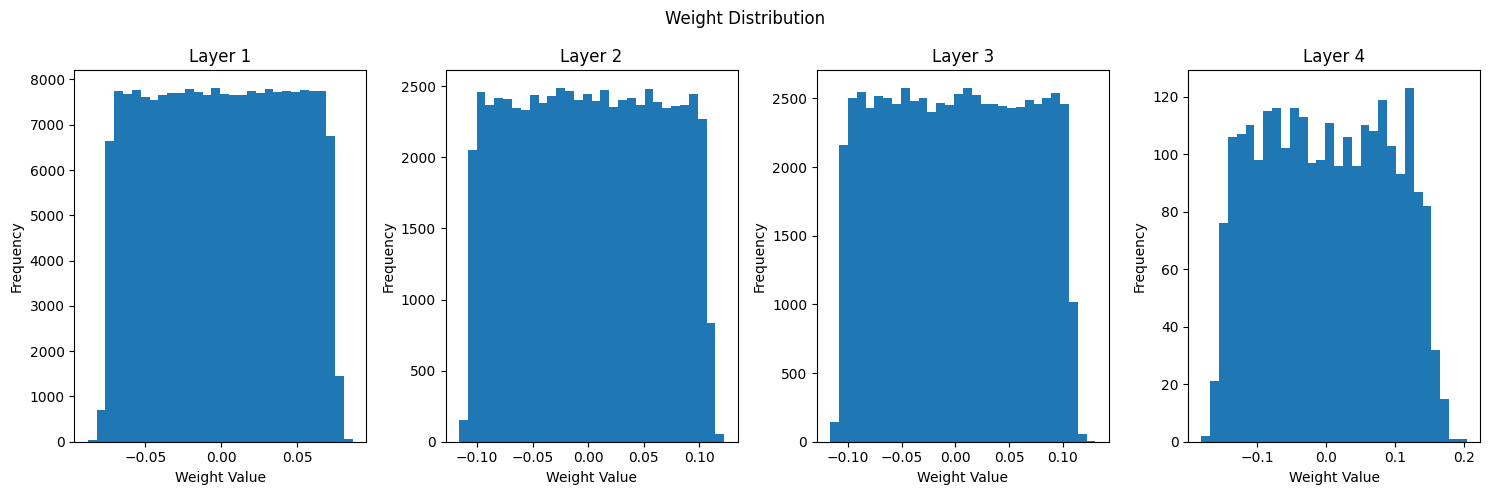


Gradient distribution for width_wide:


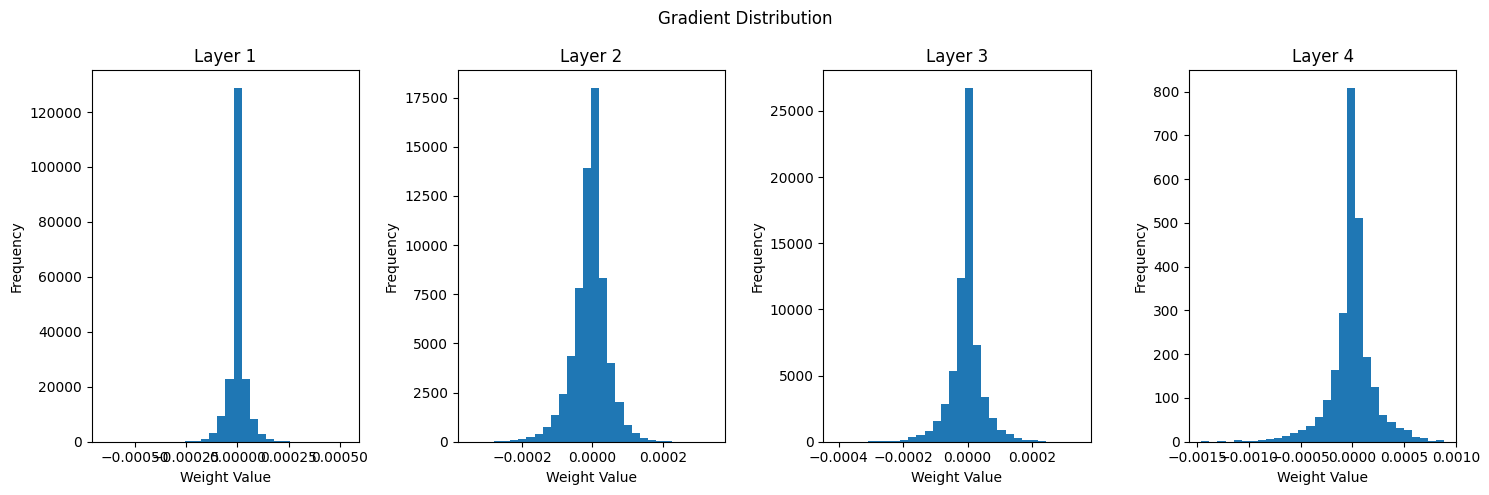

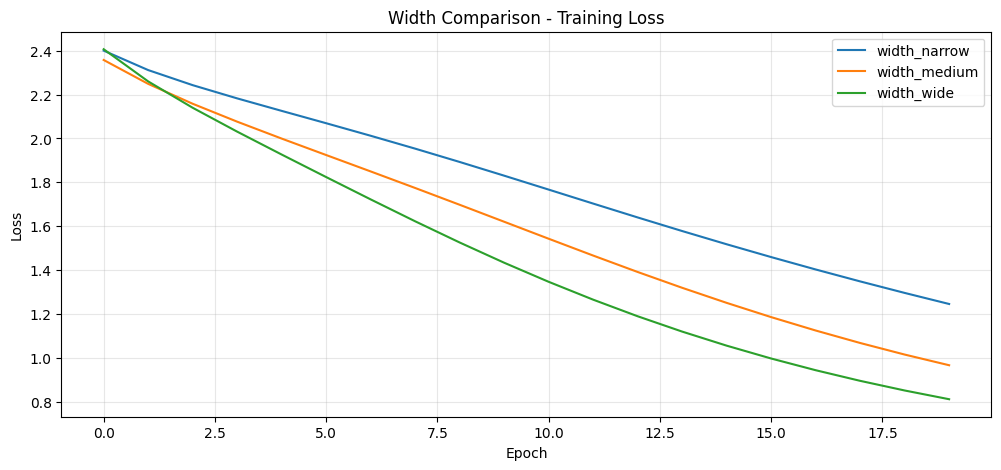

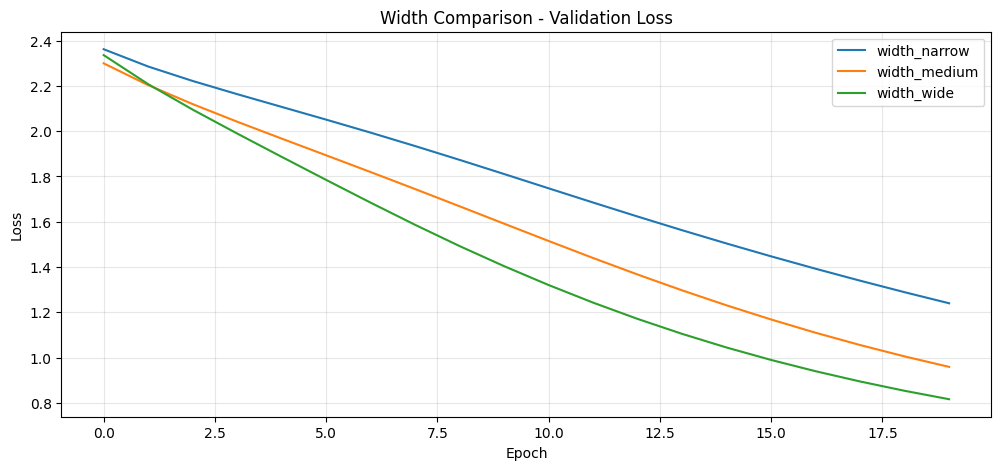

In [8]:
# Width
width_variations = [
    {'name': 'narrow', 'hidden_units': 64},
    {'name': 'medium', 'hidden_units': 128},
    {'name': 'wide', 'hidden_units': 256}
]

print("\n--- Width Experiments ---")
for variation in width_variations:
    hidden_units = variation['hidden_units']
    name = f"width_{variation['name']}"
    
    layer_sizes = [784, hidden_units, hidden_units, hidden_units, 10]
    
    print(f"\nTraining model with width={hidden_units}")
    model = FFNN(
        layer_sizes=layer_sizes,
        activations=['relu', 'relu', 'relu', 'softmax'],
        loss='categorical_cross_entropy',
        weight_initializer='xavier',
        # use_rms_norm=True
    )
    
    # Use the built-in fit method instead of manual training loop
    history = model.fit(
        X_train, 
        y_train_one_hot,
        batch_size=batch_size,
        learning_rate=learning_rate,
        epochs=epochs,
        verbose=1,
        validation_data=(X_test, y_test_one_hot)
    )
    
    models[name] = model
    histories[name] = history
    
    # Evaluate model
    print(f"\nEvaluation for {name}:")
    evaluate_model(model, X_test, y_test, y_test_one_hot)

    has_nan_weights = any(np.isnan(w).any() for w in model.weights)
    has_nan_gradients = any(np.isnan(g).any() for g in model.weight_gradients)
    
    # Plot weight distribution
    print(f"\nWeight distribution for {name}:")
    # model.plot_weight()
    if has_nan_weights:
        print("cant plot weight distribution due to NaN values")
    else:
        model.plot_weight()
    
    # Plot gradient distribution
    print(f"\nGradient distribution for {name}:")
    # model.plot_gradient_distribution()
    if has_nan_gradients:
        print("ant plot gradient distribution due to NaN values")
    else:
        model.plot_gradient_distribution()

plot_comparison(histories, "Width Comparison - Training Loss", "train_loss")
plot_comparison(histories, "Width Comparison - Validation Loss", "val_loss")


--- Depth Experiments ---

Training model with depth=1 (hidden layers)


Epoch 1/20:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 270.68it/s]


Epoch 1/20 - 2.36s - loss: 2.4999 - val_loss: 2.2723 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 276.18it/s]


...

Epoch 18/20 - 2.29s - loss: 0.7482 - val_loss: 0.7664 - lr: 0.007093


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 273.88it/s]


Epoch 19/20 - 2.33s - loss: 0.7298 - val_loss: 0.7492 - lr: 0.006951


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 278.46it/s]


Epoch 20/20 - 2.30s - loss: 0.7130 - val_loss: 0.7334 - lr: 0.006812

Evaluation for depth_shallow:
Test accuracy: 0.8070


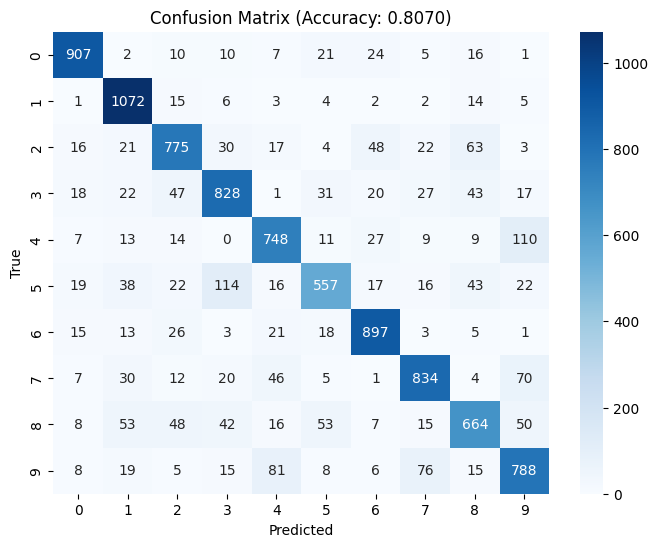


Weight distribution for depth_shallow:


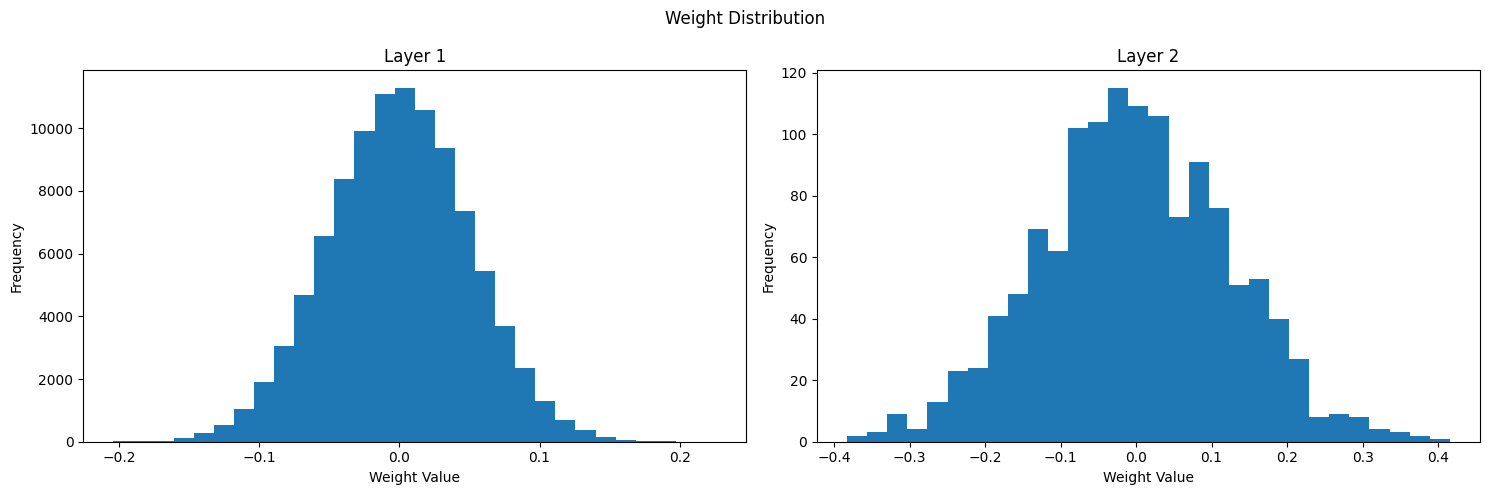


Gradient distribution for depth_shallow:


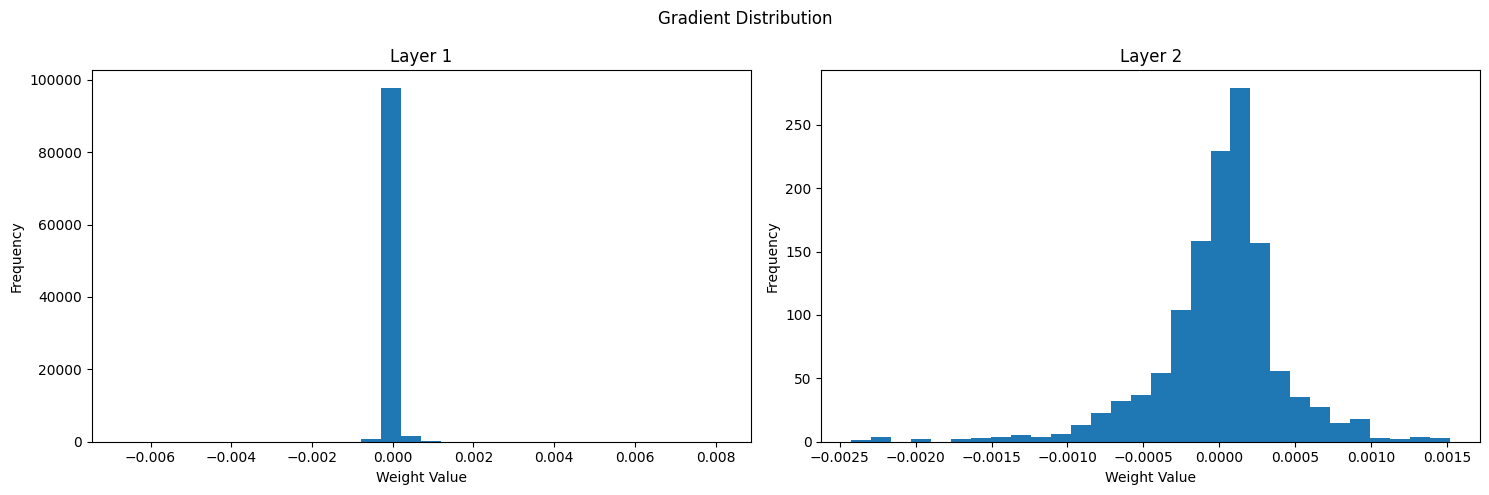


Training model with depth=4 (hidden layers)


Epoch 1/20: 100%|██████████| 625/625 [00:03<00:00, 194.59it/s]


Epoch 1/20 - 3.31s - loss: 2.4192 - val_loss: 2.2426 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:03<00:00, 193.10it/s]


Epoch 2/20 - 3.34s - loss: 2.1203 - val_loss: 2.0067 - lr: 0.009800


...

Epoch 18/20 - 3.44s - loss: 0.7369 - val_loss: 0.7275 - lr: 0.007093


Epoch 19/20: 100%|██████████| 625/625 [00:03<00:00, 190.61it/s]


Epoch 19/20 - 3.37s - loss: 0.7130 - val_loss: 0.7057 - lr: 0.006951


Epoch 20/20: 100%|██████████| 625/625 [00:03<00:00, 192.13it/s]


Epoch 20/20 - 3.33s - loss: 0.6914 - val_loss: 0.6859 - lr: 0.006812

Evaluation for depth_medium:
Test accuracy: 0.8120


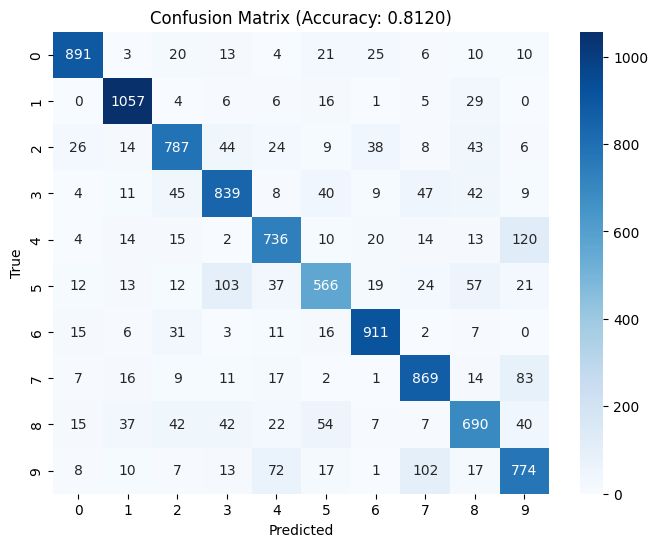


Weight distribution for depth_medium:


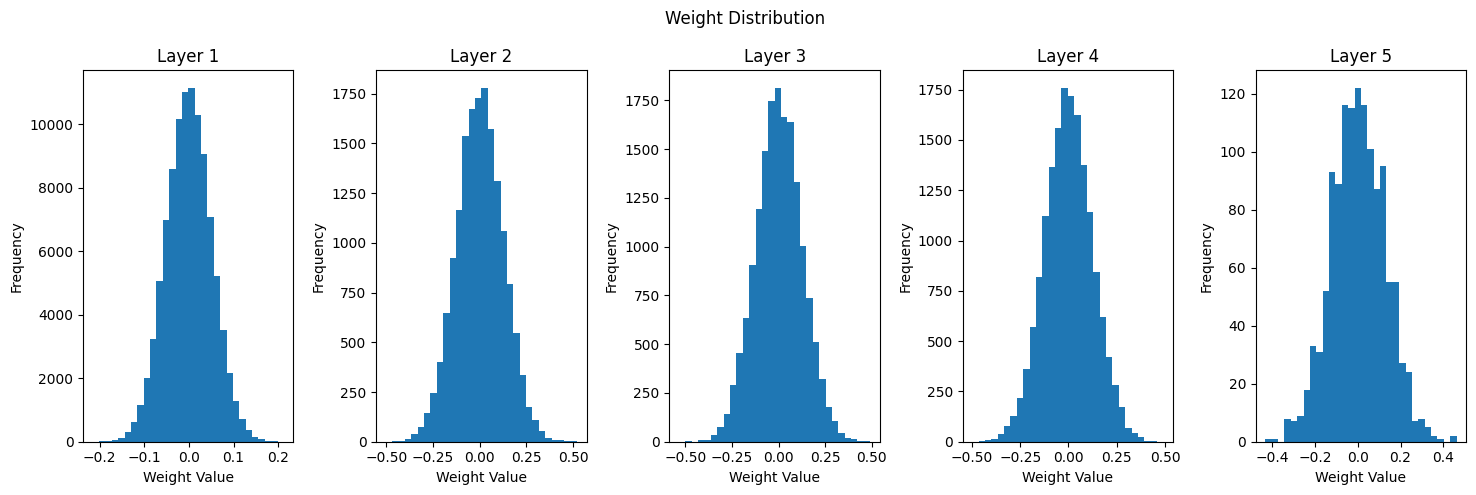


Gradient distribution for depth_medium:


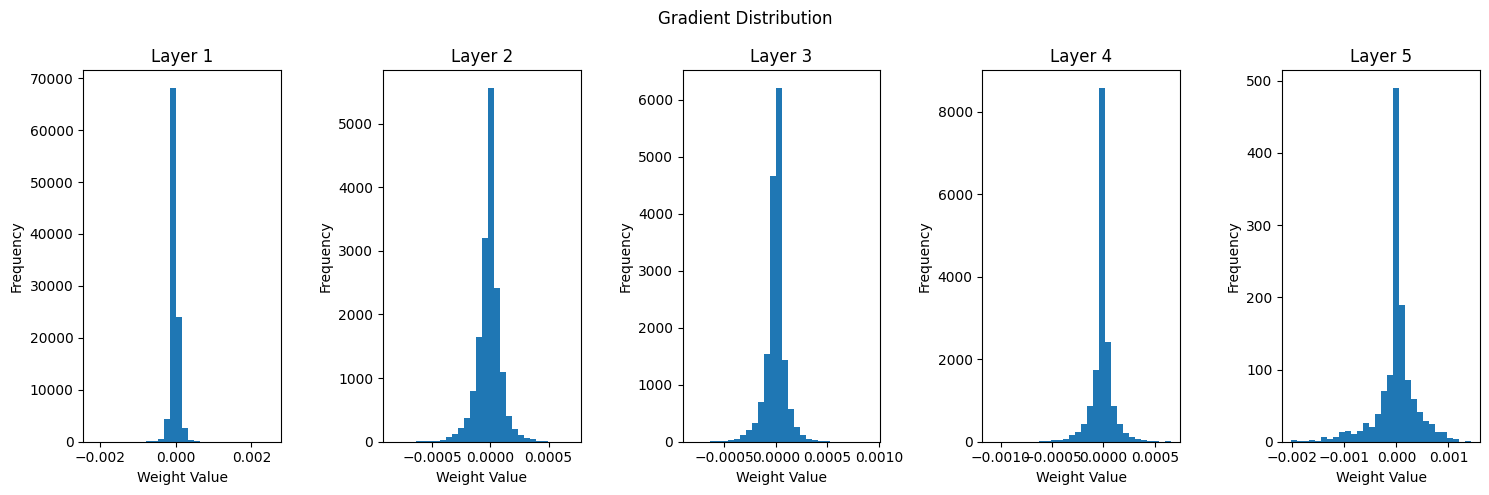


Training model with depth=8 (hidden layers)


Epoch 1/20: 100%|██████████| 625/625 [00:04<00:00, 142.11it/s]


Epoch 1/20 - 4.54s - loss: 2.4495 - val_loss: 2.3039 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:04<00:00, 142.60it/s]


Epoch 2/20 - 4.51s - loss: 2.2340 - val_loss: 2.1759 - lr: 0.009800


...

Epoch 18/20 - 4.55s - loss: 0.8492 - val_loss: 0.8545 - lr: 0.007093


Epoch 19/20: 100%|██████████| 625/625 [00:04<00:00, 134.78it/s]


Epoch 19/20 - 4.78s - loss: 0.8150 - val_loss: 0.8235 - lr: 0.006951


Epoch 20/20: 100%|██████████| 625/625 [00:04<00:00, 140.68it/s]


Epoch 20/20 - 4.58s - loss: 0.7845 - val_loss: 0.7957 - lr: 0.006812

Evaluation for depth_deep:
Test accuracy: 0.7611


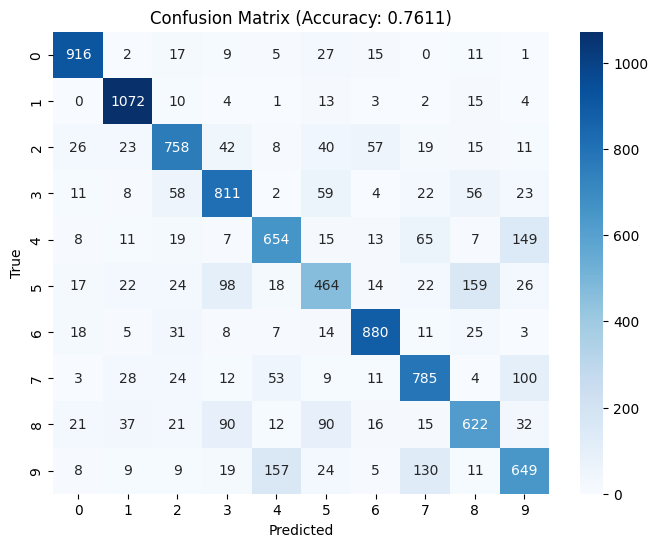


Weight distribution for depth_deep:


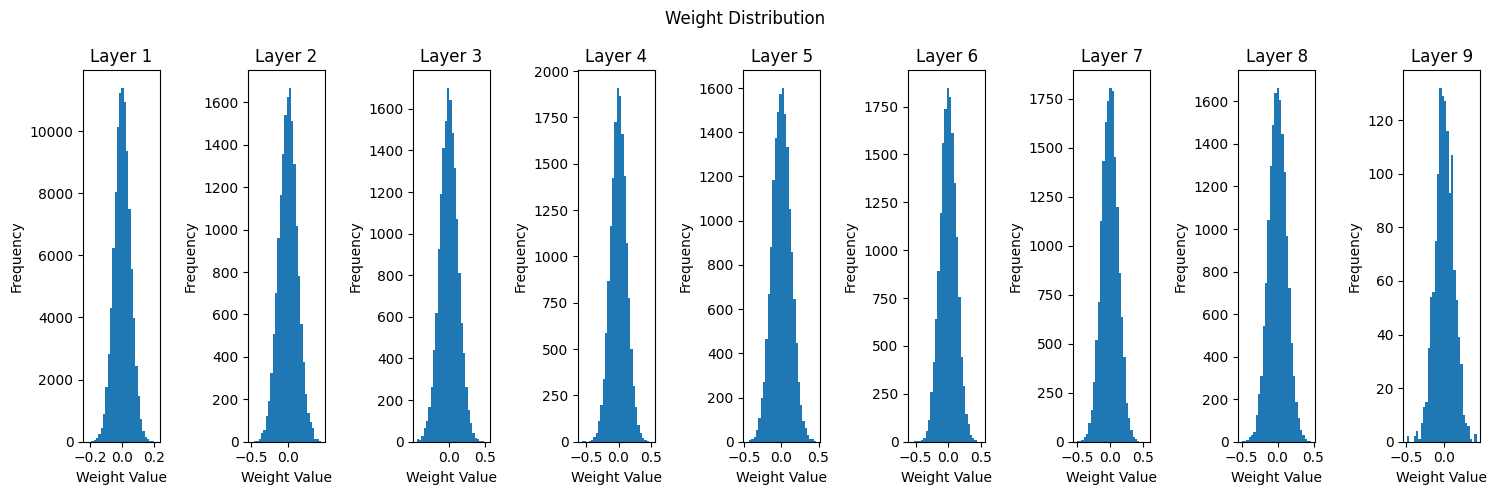


Gradient distribution for depth_deep:


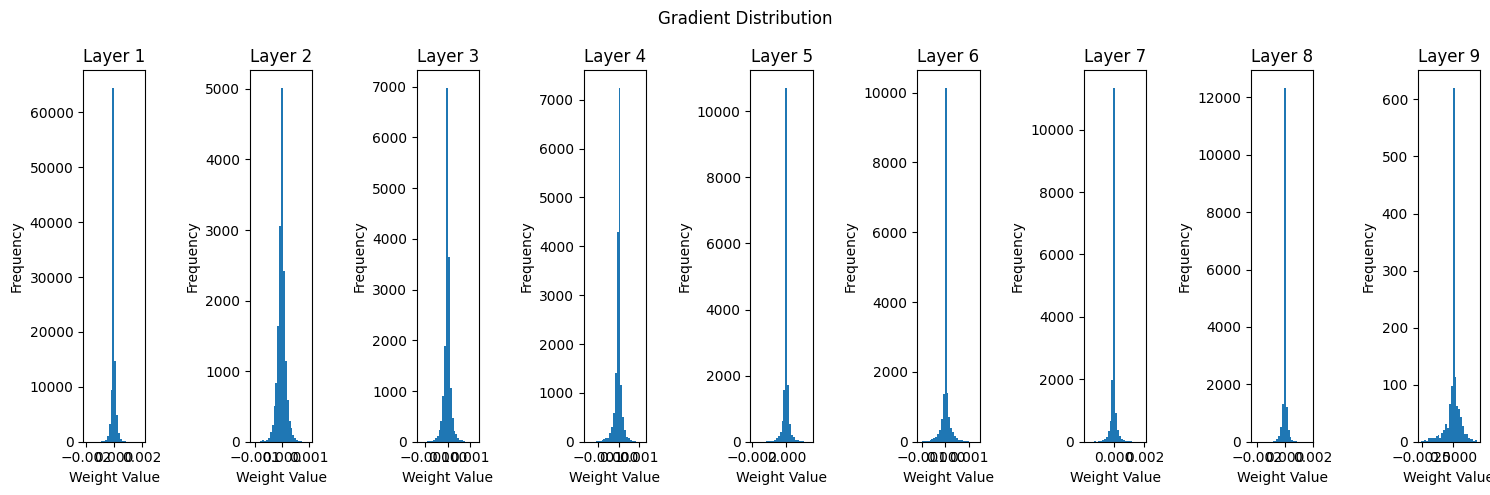

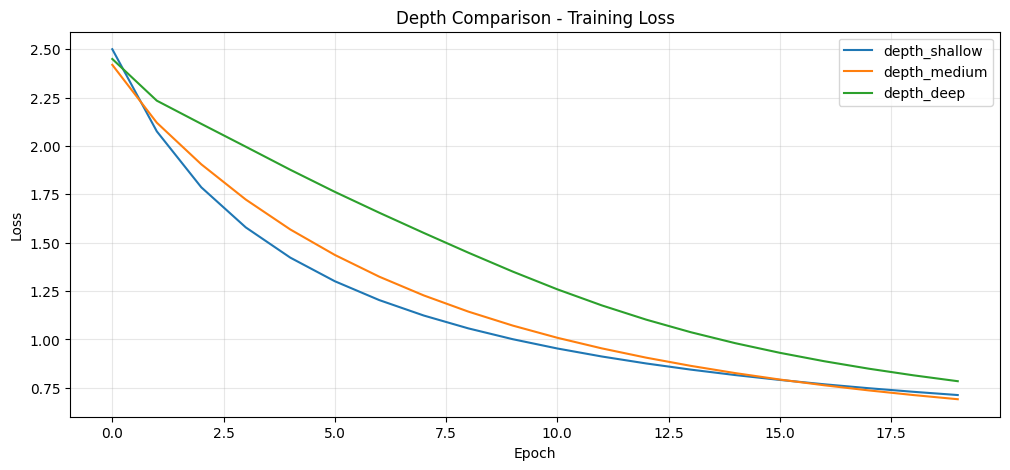

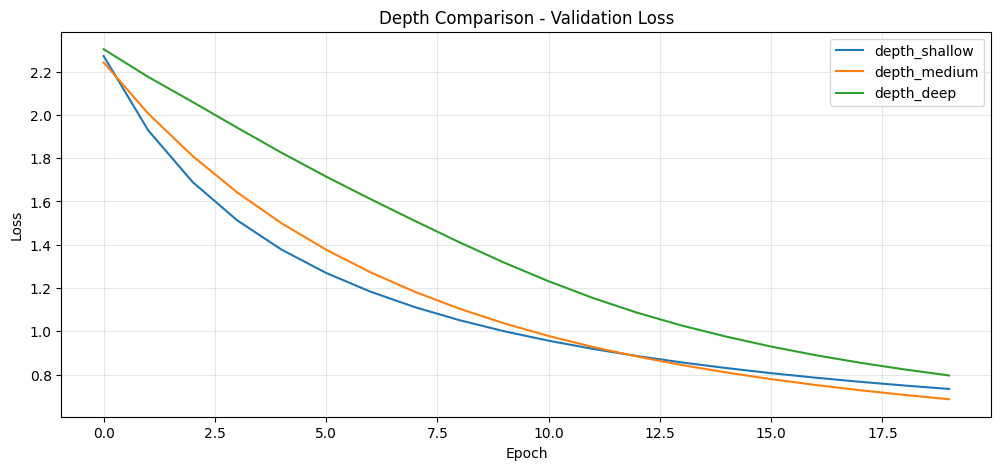

In [10]:
# Depth
depth_variations = [
    {'name': 'shallow', 'n_layers': 1},
    {'name': 'medium', 'n_layers': 4},
    {'name': 'deep', 'n_layers': 8}
]

fixed_width = 128

print("\n--- Depth Experiments ---")
models = {}
histories = {}

for variation in depth_variations:
    n_layers = variation['n_layers']
    name = f"depth_{variation['name']}"
    
    layer_sizes = [784] + [fixed_width] * n_layers + [10]
    activations = ['relu'] * n_layers + ['softmax']
    
    print(f"\nTraining model with depth={n_layers} (hidden layers)")
    model = FFNN(
        layer_sizes=layer_sizes,
        activations=activations,
        loss='categorical_cross_entropy',
        weight_initializer='he',
        # use_rms_norm=True
    )
    
    history = model.fit(
        X_train, 
        y_train_one_hot,
        batch_size=batch_size,
        learning_rate=learning_rate,
        epochs=epochs,
        verbose=1,
        validation_data=(X_test, y_test_one_hot),
        gradient_clip=1.0,
        learning_rate_decay=0.98,
        early_stopping_patience=10
    )
    
    models[name] = model
    histories[name] = history
    
    # Evaluate model
    print(f"\nEvaluation for {name}:")
    evaluate_model(model, X_test, y_test, y_test_one_hot)

    has_nan_weights = any(np.isnan(w).any() for w in model.weights)
    has_nan_gradients = any(np.isnan(g).any() for g in model.weight_gradients)
    
    # Plot weight distribution
    print(f"\nWeight distribution for {name}:")
    if has_nan_weights:
        print("cannot plot weight distribution due to nan values")
    else:
        model.plot_weight()
    
    # Plot gradient distribution
    print(f"\nGradient distribution for {name}:")
    if has_nan_gradients:
        print("cannot plot gradient distribution due to nan values")
    else:
        model.plot_gradient_distribution()

plot_comparison({k: v for k, v in histories.items() if k.startswith("depth_")}, 
               "Depth Comparison - Training Loss", "train_loss")
plot_comparison({k: v for k, v in histories.items() if k.startswith("depth_")}, 
               "Depth Comparison - Validation Loss", "val_loss")

## Activation Functions


--- Activation Function Experiments ---

Training model with activation=linear


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 252.26it/s]


Epoch 1/20 - 2.53s - loss: 2.4683 - val_loss: 1.9547 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 268.47it/s]


Epoch 2/20 - 2.38s - loss: 1.6577 - val_loss: 1.4575 - lr: 0.009800


...

Epoch 18/20 - 2.60s - loss: 0.5651 - val_loss: 0.5942 - lr: 0.007093


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 267.90it/s]


Epoch 19/20 - 2.38s - loss: 0.5555 - val_loss: 0.5853 - lr: 0.006951


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 247.62it/s]


Epoch 20/20 - 2.57s - loss: 0.5468 - val_loss: 0.5773 - lr: 0.006812

Evaluation for activation_linear:
Test accuracy: 0.8432


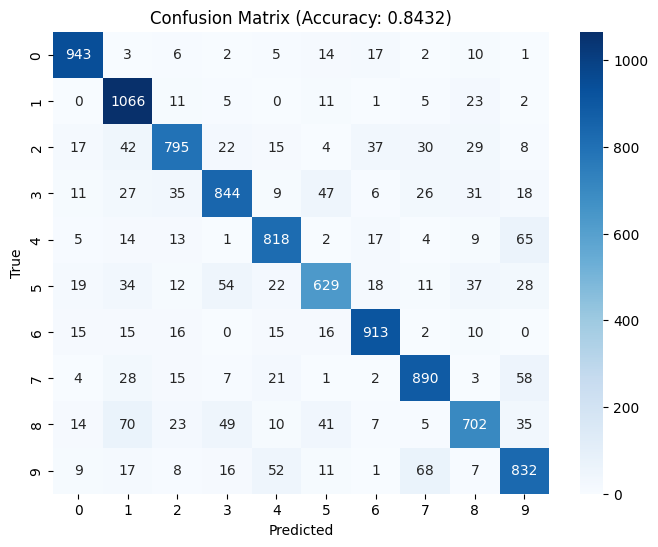


Weight distribution for activation_linear:


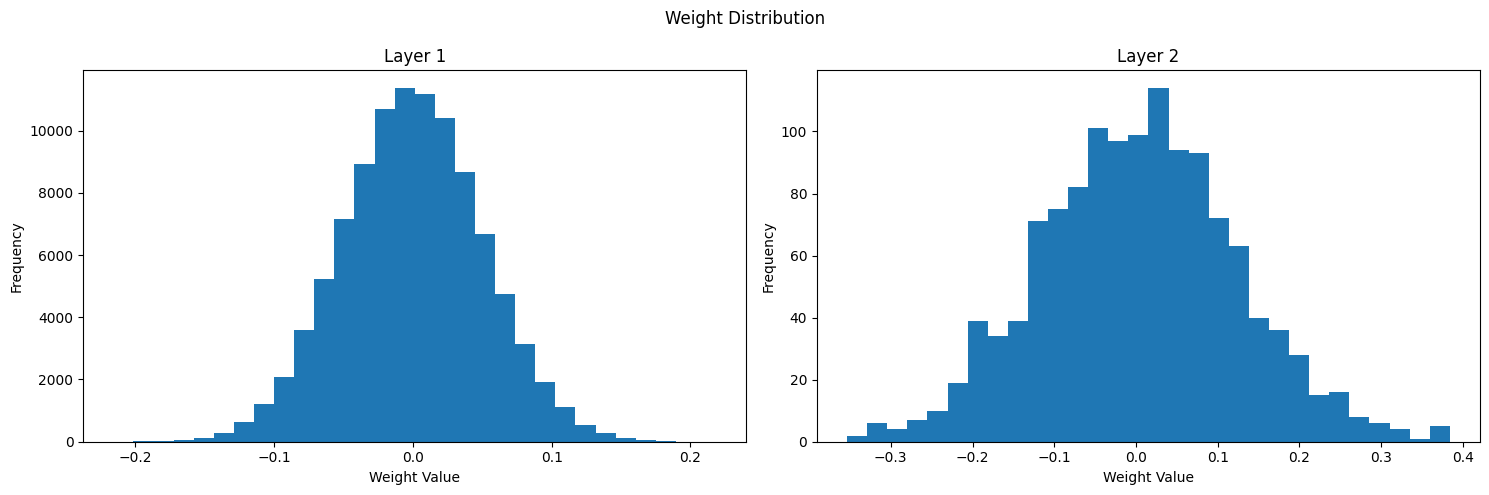


Gradient distribution for activation_linear:


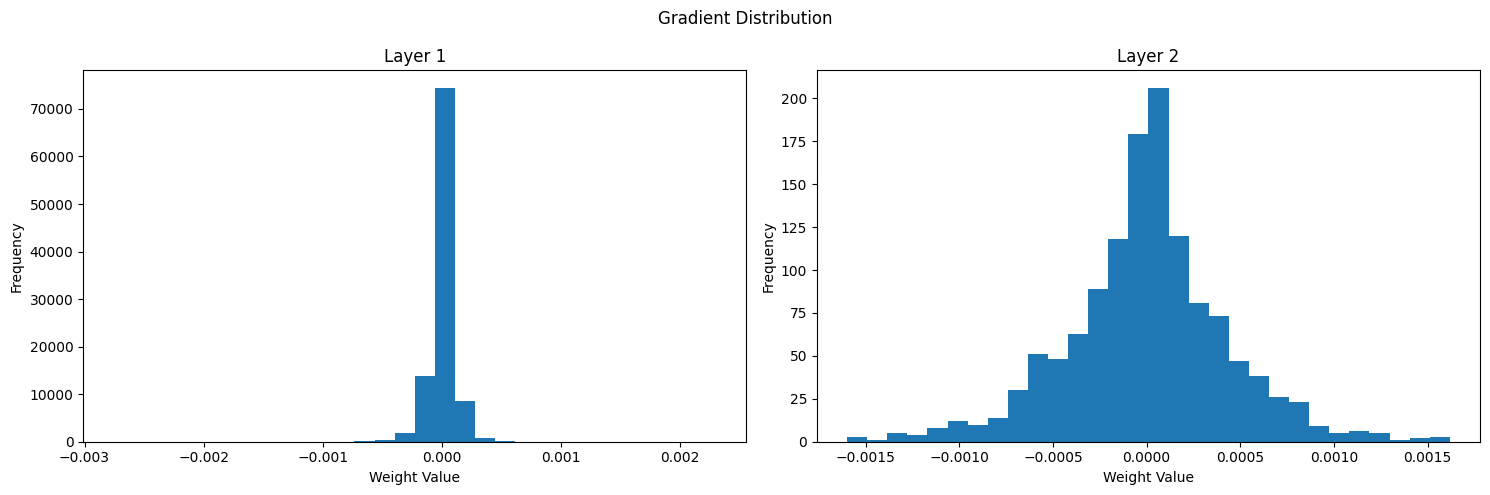


Training model with activation=relu


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 262.05it/s]


Epoch 1/20 - 2.44s - loss: 2.5116 - val_loss: 2.2561 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 262.94it/s]


Epoch 2/20 - 2.43s - loss: 2.0570 - val_loss: 1.8991 - lr: 0.009800


...

Epoch 18/20 - 2.31s - loss: 0.7364 - val_loss: 0.7543 - lr: 0.007093


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 284.48it/s]


Epoch 19/20 - 2.25s - loss: 0.7186 - val_loss: 0.7376 - lr: 0.006951


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 281.28it/s]


Epoch 20/20 - 2.27s - loss: 0.7024 - val_loss: 0.7224 - lr: 0.006812

Evaluation for activation_relu:
Test accuracy: 0.8074


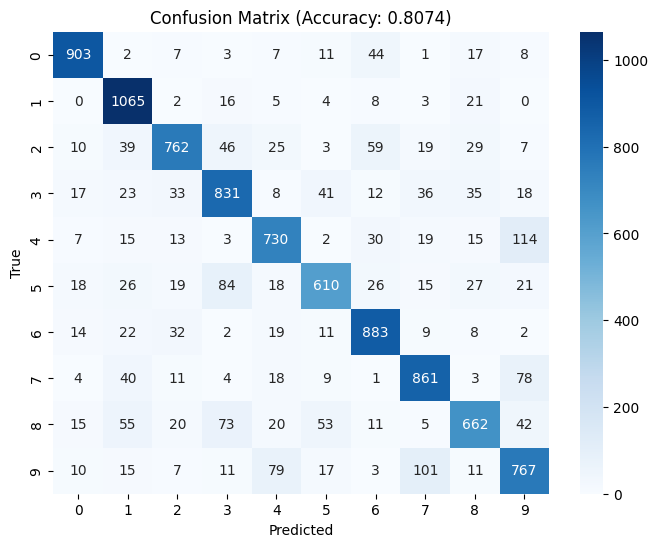


Weight distribution for activation_relu:


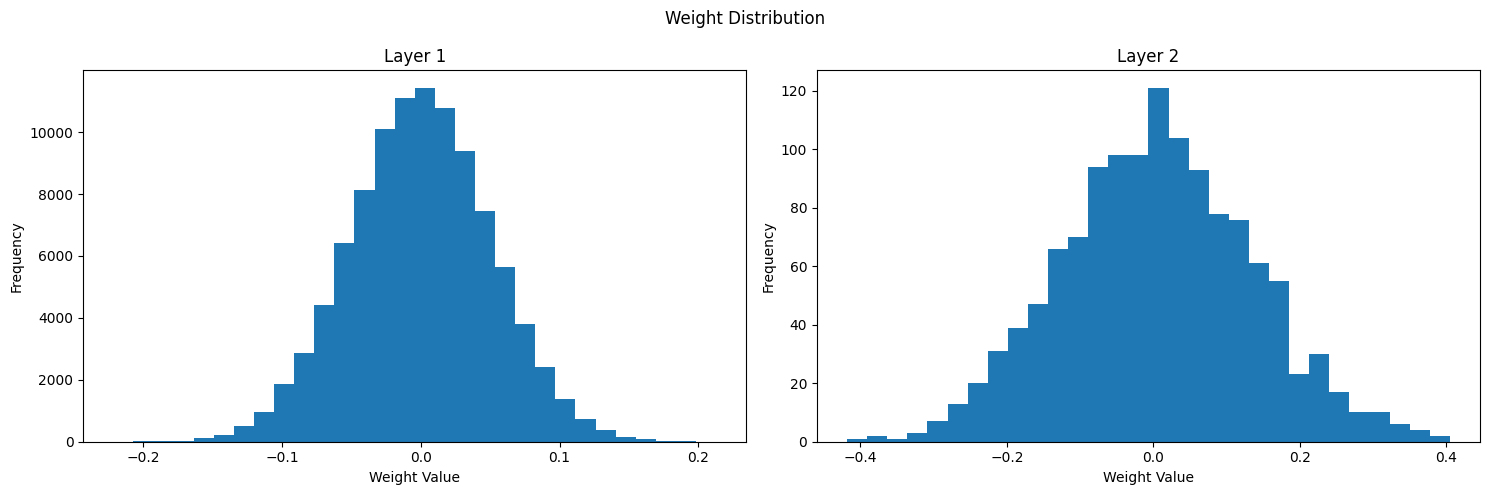


Gradient distribution for activation_relu:


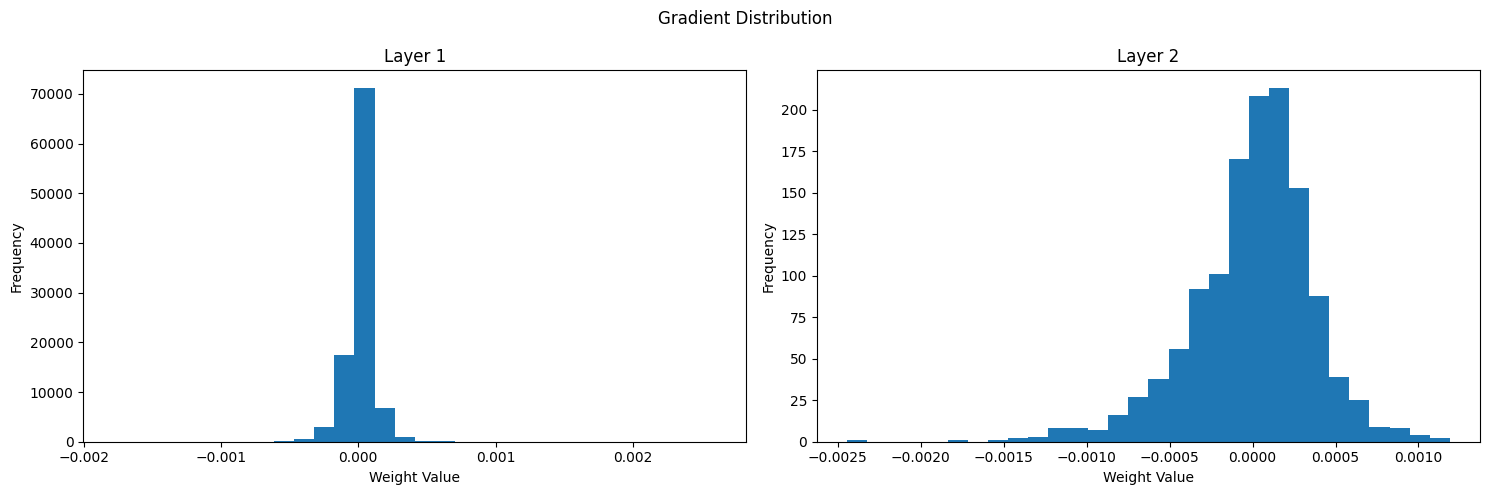


Training model with activation=sigmoid


Epoch 1/20:   0%|          | 0/625 [00:00<?, ?it/s]d:\Personal Doc\Projects\College\Tubes_ML\src\models\activations.py:48: RuntimeWarning: invalid value encountered in add
  result[mask] = result[mask] / (1 + result[mask])
d:\Personal Doc\Projects\College\Tubes_ML\src\models\activations.py:48: RuntimeWarning: invalid value encountered in divide
  result[mask] = result[mask] / (1 + result[mask])
Epoch 1/20:   4%|▎         | 22/625 [00:00<00:02, 217.83it/s]

Reducing learning rate and skipping batch...
Reducing learning rate and skipping batch...
Reducing learning rate and skipping batch...


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 223.41it/s]


Epoch 1/20 - 2.91s - loss: 2.5682 - val_loss: 2.5804 - lr: 0.001250


...

Epoch 18/20 - 2.77s - loss: 2.4015 - val_loss: 2.4174 - lr: 0.000887


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 233.30it/s]


Epoch 19/20 - 2.79s - loss: 2.3953 - val_loss: 2.4108 - lr: 0.000869


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 238.21it/s]


Epoch 20/20 - 2.73s - loss: 2.3890 - val_loss: 2.4042 - lr: 0.000852

Evaluation for activation_sigmoid:
Test accuracy: 0.1018


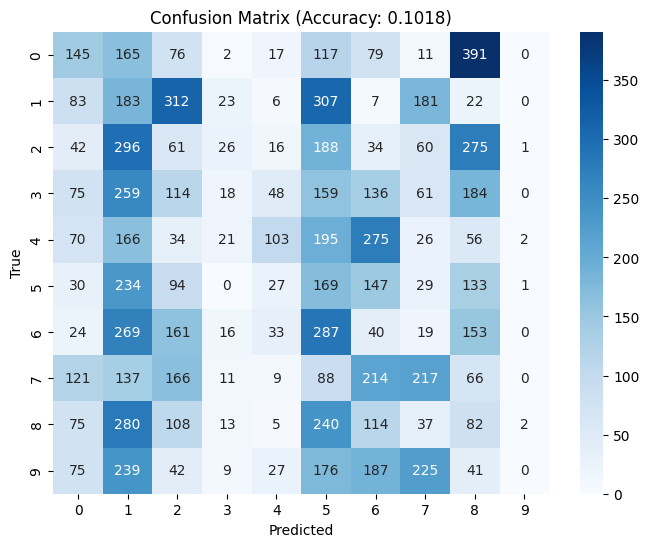


Weight distribution for activation_sigmoid:


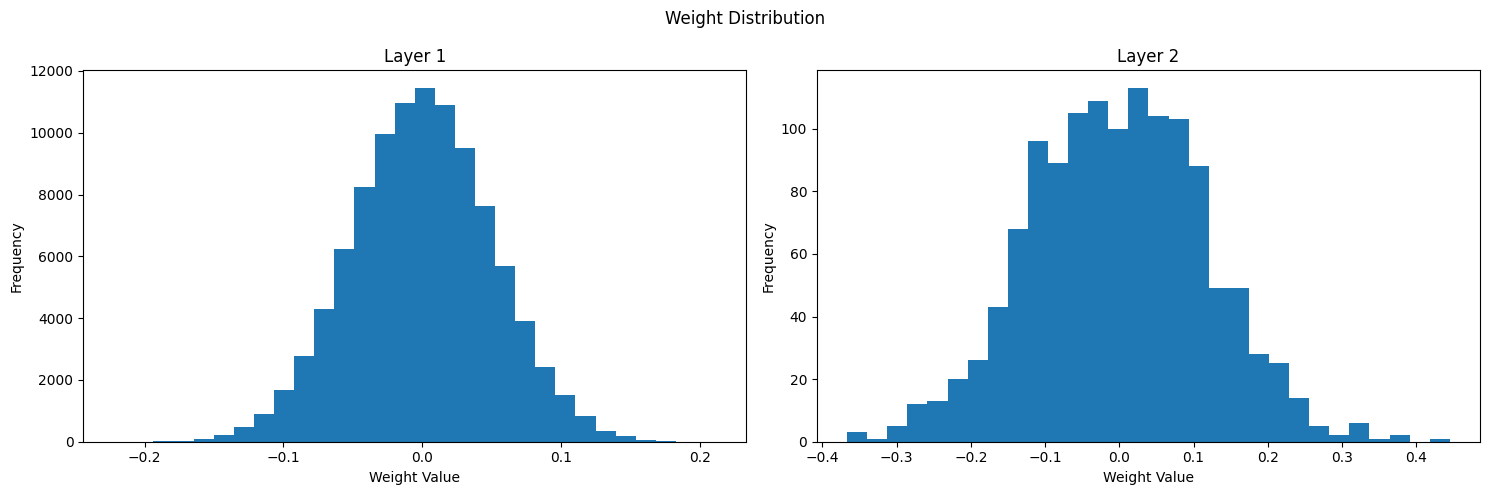


Gradient distribution for activation_sigmoid:


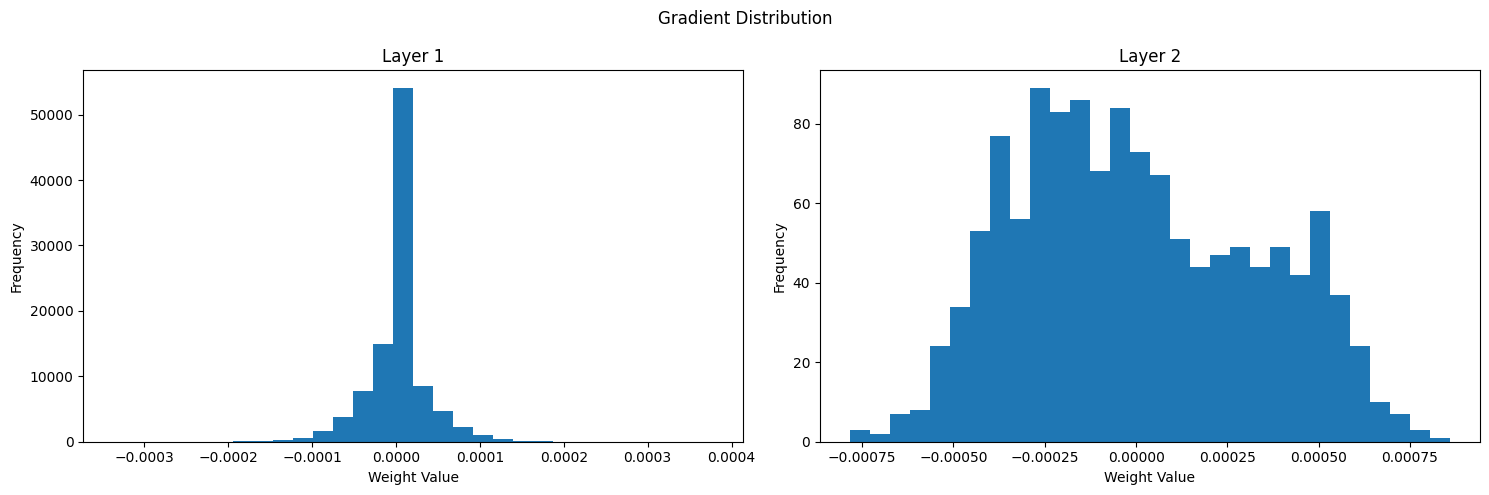


Training model with activation=tanh


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 280.66it/s]


Epoch 1/20 - 2.28s - loss: 2.3487 - val_loss: 2.0919 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 273.52it/s]


Epoch 2/20 - 2.34s - loss: 1.9058 - val_loss: 1.7418 - lr: 0.009800


...

Epoch 18/20 - 2.29s - loss: 0.7203 - val_loss: 0.7212 - lr: 0.007093


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 278.77it/s]


Epoch 19/20 - 2.30s - loss: 0.7053 - val_loss: 0.7073 - lr: 0.006951


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 269.63it/s]


Epoch 20/20 - 2.38s - loss: 0.6917 - val_loss: 0.6945 - lr: 0.006812

Evaluation for activation_tanh:
Test accuracy: 0.8059


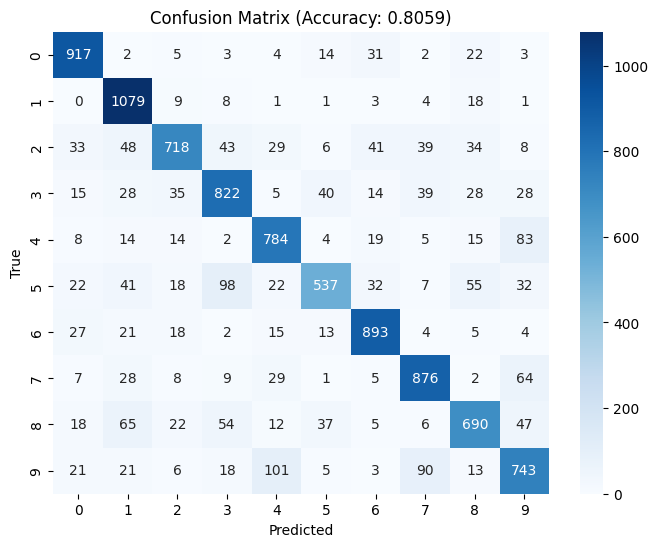


Weight distribution for activation_tanh:


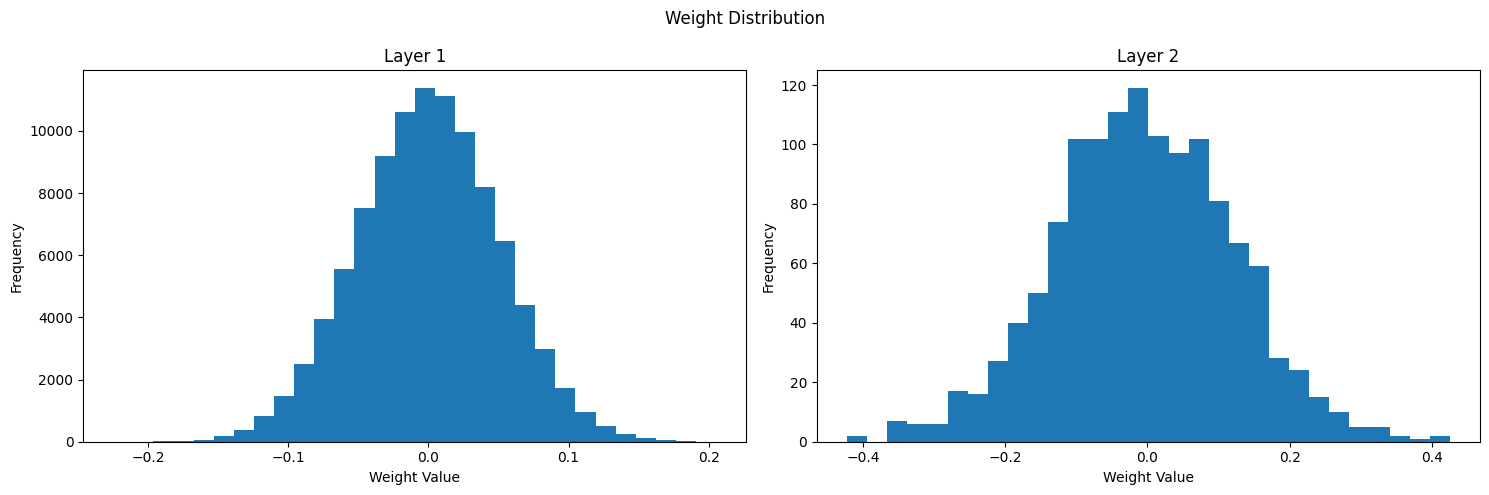


Gradient distribution for activation_tanh:


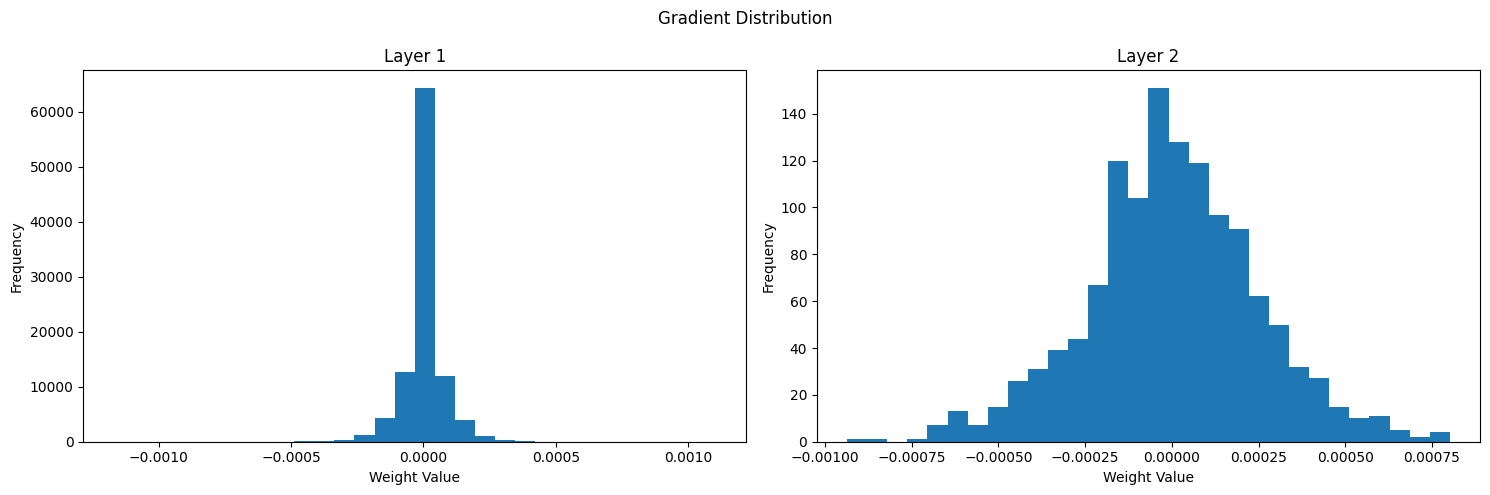

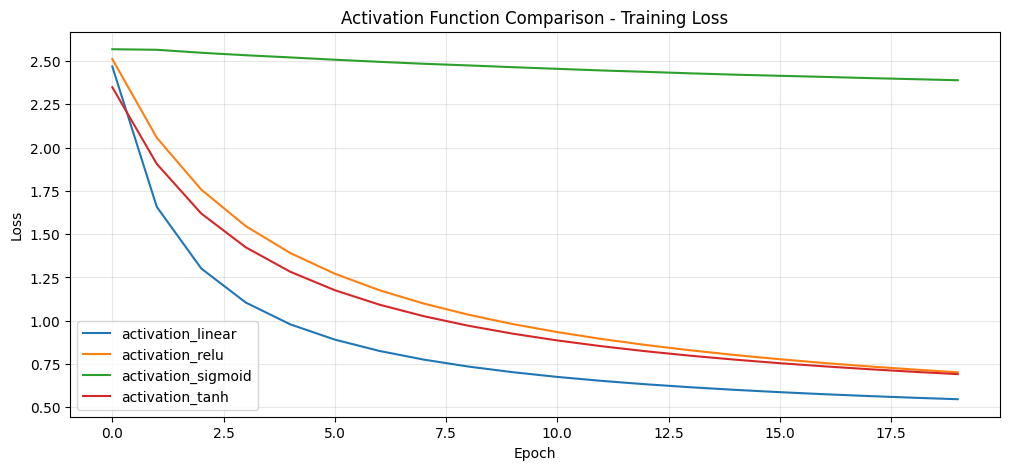

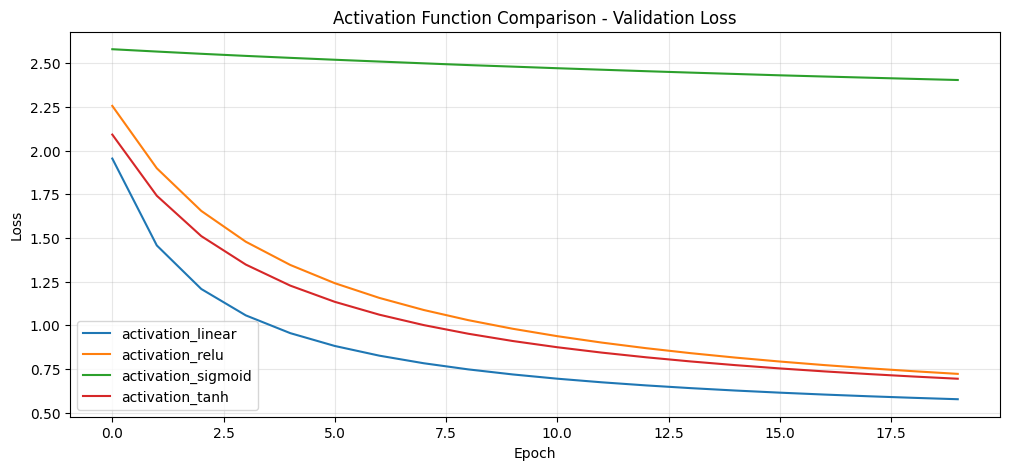

In [11]:
activation_functions = ['linear', 'relu', 'sigmoid', 'tanh']

fixed_width = 128
fixed_layer_sizes = [784, fixed_width, 10]

activation_models = {}
activation_histories = {}

print("\n--- Activation Function Experiments ---")
for activation in activation_functions:
    name = f"activation_{activation}"
    
    print(f"\nTraining model with activation={activation}")
    model = FFNN(
        layer_sizes=fixed_layer_sizes,
        activations=[activation, 'softmax'],
        loss='categorical_cross_entropy',
        weight_initializer='he',
        # use_rms_norm=True
    )
    
    # Use the new fit method instead of manual training loop
    history = model.fit(
        X_train, 
        y_train_one_hot,
        batch_size=batch_size,
        learning_rate=learning_rate,
        epochs=epochs,
        verbose=1,
        validation_data=(X_test, y_test_one_hot),
        gradient_clip=1.0,
        learning_rate_decay=0.98,
        early_stopping_patience=5 
    )
    
    activation_models[name] = model
    activation_histories[name] = history
    
    # Evaluate model
    print(f"\nEvaluation for {name}:")
    evaluate_model(model, X_test, y_test, y_test_one_hot)

    has_nan_weights = any(np.isnan(w).any() for w in model.weights)
    has_nan_gradients = any(np.isnan(g).any() for g in model.weight_gradients)
    
    # Plot weight distribution
    print(f"\nWeight distribution for {name}:")
    if has_nan_weights:
        print("can't plot weight distribution due to nan values")
    else:
        model.plot_weight()
    
    # Plot gradient distribution
    print(f"\nGradient distribution for {name}:")
    if has_nan_gradients:
        print("can't plot gradient distribution due to nan values")
    else:
        model.plot_gradient_distribution()

plot_comparison(activation_histories, "Activation Function Comparison - Training Loss", "train_loss")
plot_comparison(activation_histories, "Activation Function Comparison - Validation Loss", "val_loss")

## Learning Rate


--- Learning Rate Experiments ---

Training model with learning_rate=0.001


Epoch 1/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.3261 - val_loss: 2.3314


Epoch 2/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.3250 - val_loss: 2.3303


...

Epoch 18/20 - loss: 2.3069 - val_loss: 2.3117


Epoch 19/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 19/20 - loss: 2.3057 - val_loss: 2.3106


Epoch 20/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 20/20 - loss: 2.3046 - val_loss: 2.3094

Evaluation for lr_0.001:
Test accuracy: 0.0875


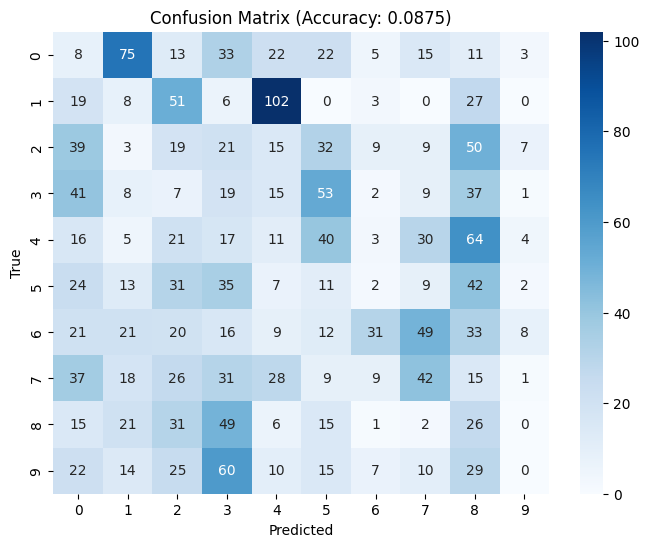


Weight distribution for lr_0.001:


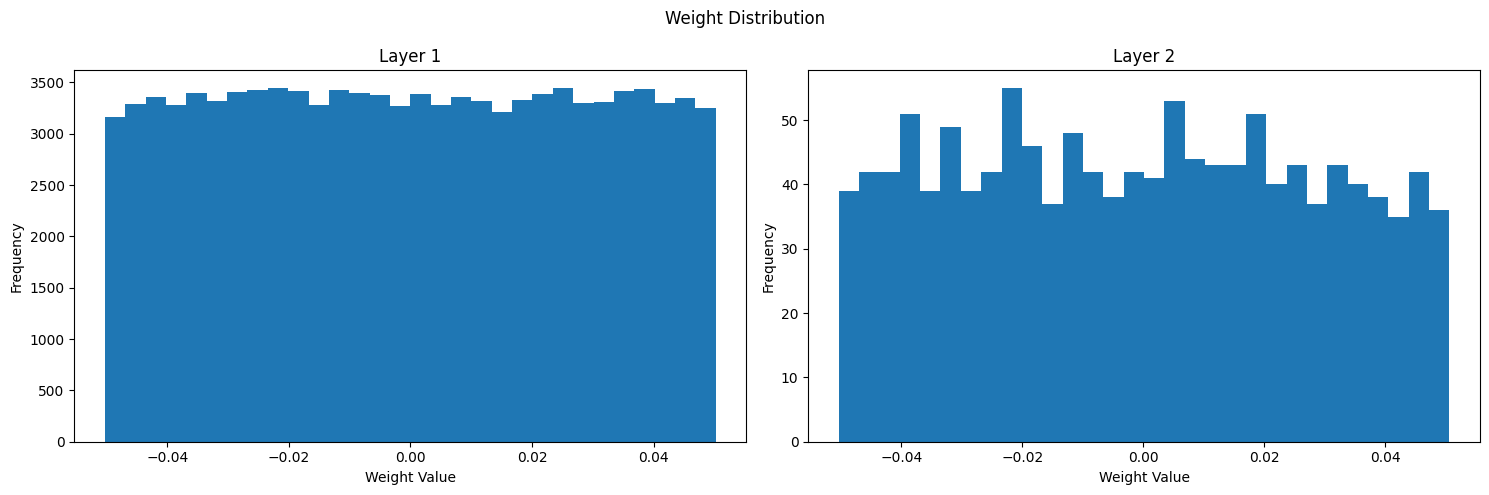


Gradient distribution for lr_0.001:


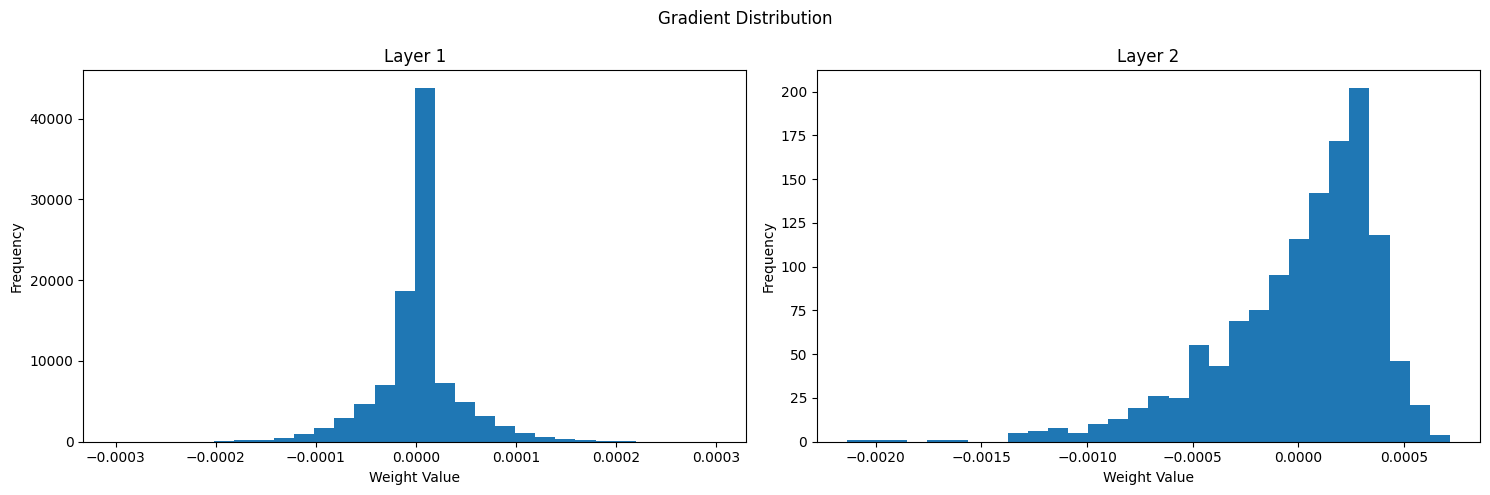


Training model with learning_rate=0.01


Epoch 1/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.3075 - val_loss: 2.3048


Epoch 2/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.2973 - val_loss: 2.2945


...

Epoch 18/20 - loss: 2.1393 - val_loss: 2.1347


Epoch 19/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 19/20 - loss: 2.1294 - val_loss: 2.1246


Epoch 20/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 20/20 - loss: 2.1195 - val_loss: 2.1145

Evaluation for lr_0.01:
Test accuracy: 0.5070


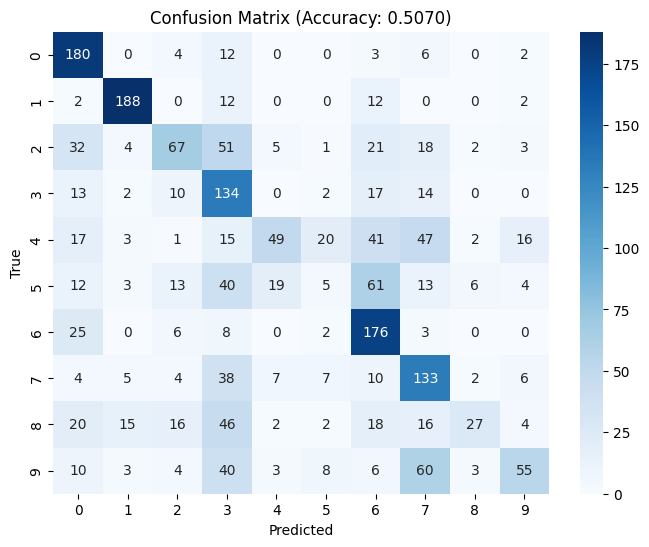


Weight distribution for lr_0.01:


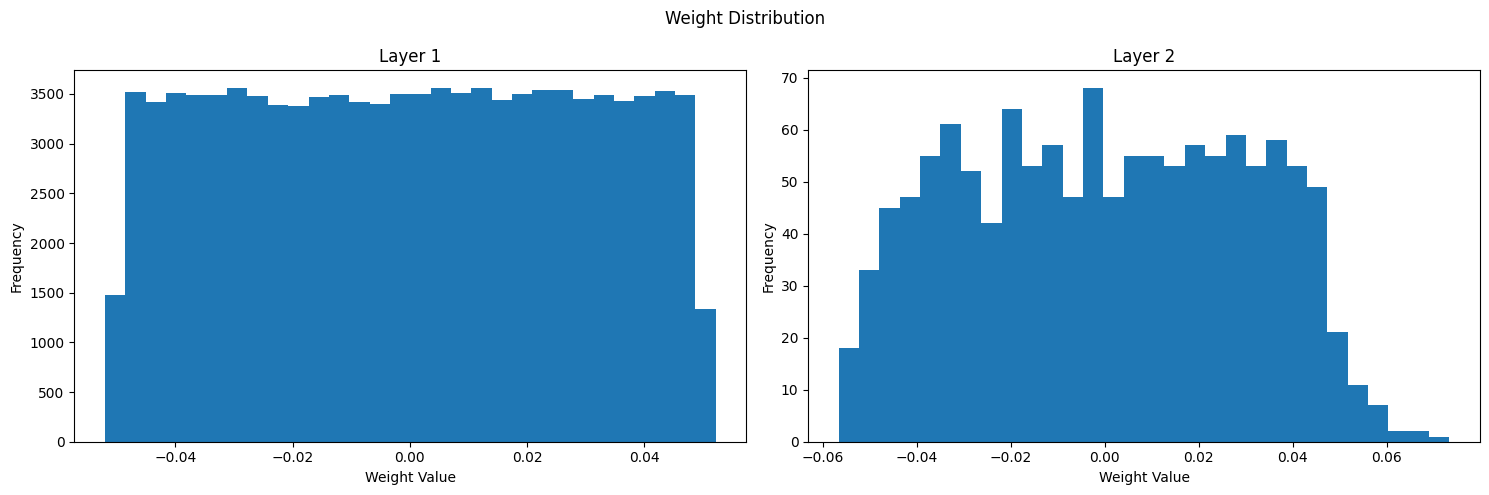


Gradient distribution for lr_0.01:


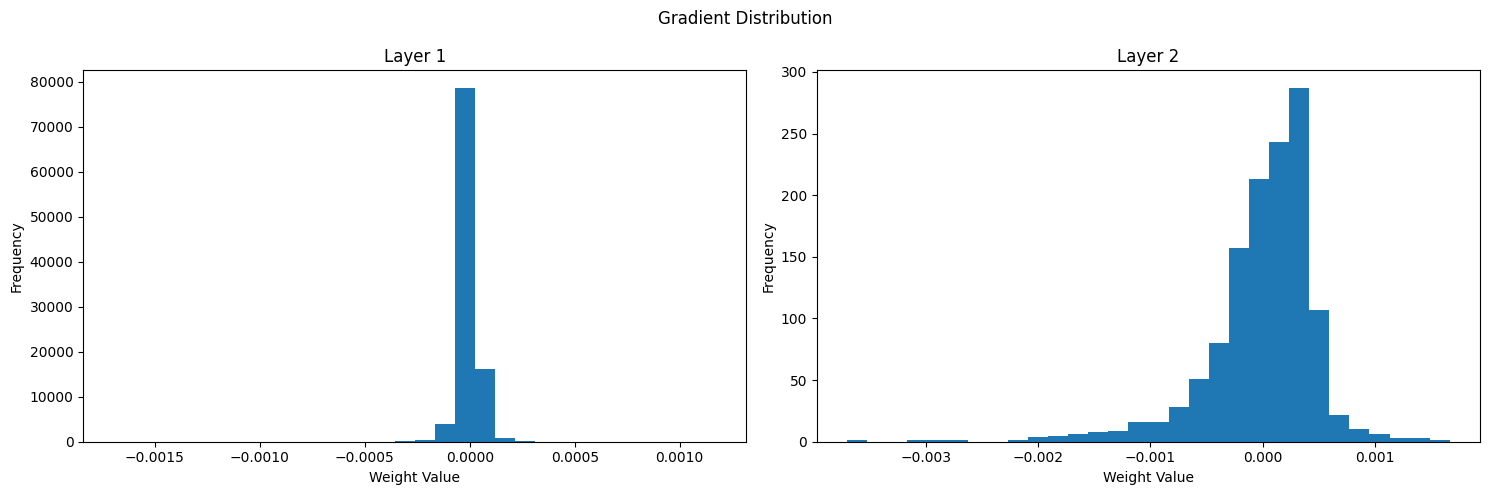


Training model with learning_rate=0.1


Epoch 1/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.2702 - val_loss: 2.2128


Epoch 2/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.1613 - val_loss: 2.1030


...

Epoch 18/20 - loss: 0.7117 - val_loss: 0.6771


Epoch 19/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 19/20 - loss: 0.6764 - val_loss: 0.6450


Epoch 20/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 20/20 - loss: 0.6450 - val_loss: 0.6166

Evaluation for lr_0.1:
Test accuracy: 0.8570


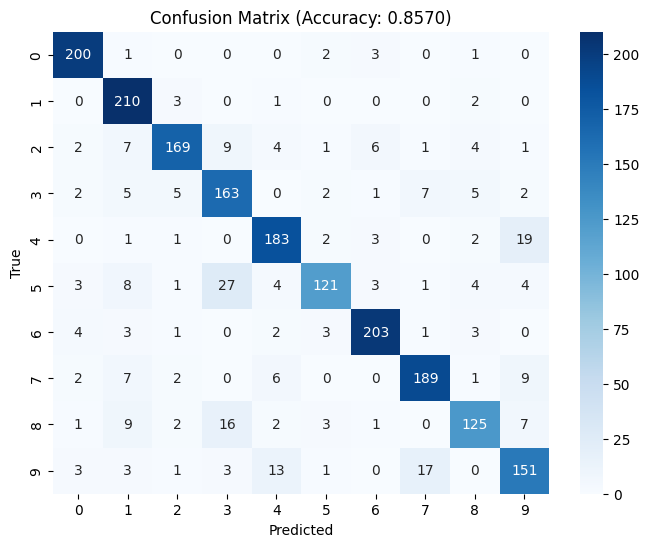


Weight distribution for lr_0.1:


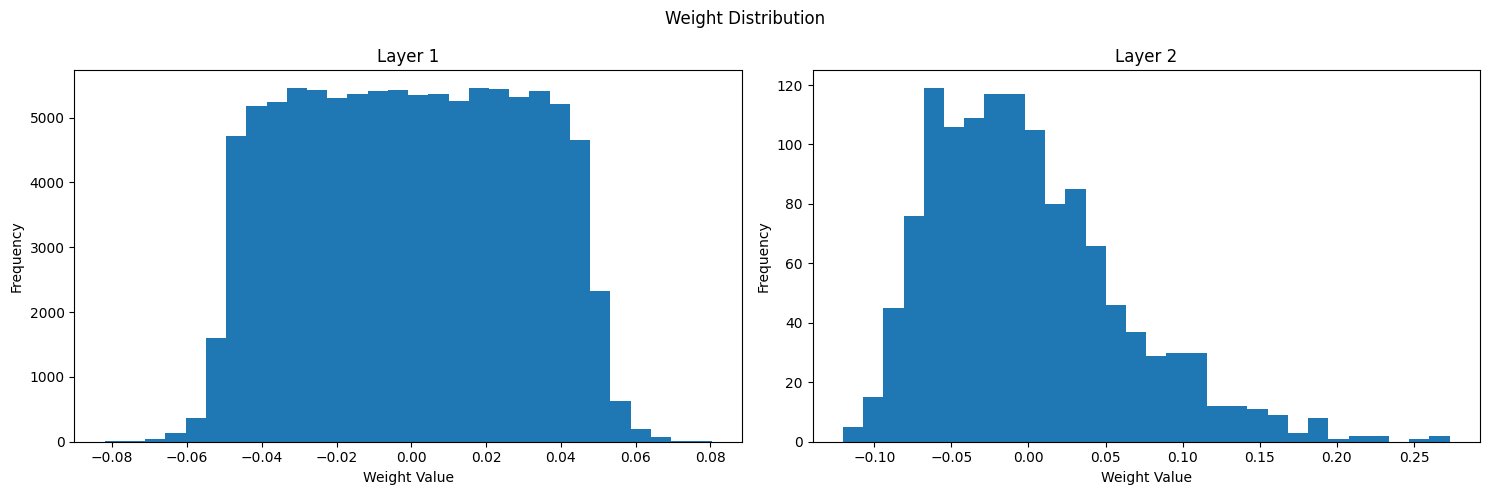


Gradient distribution for lr_0.1:


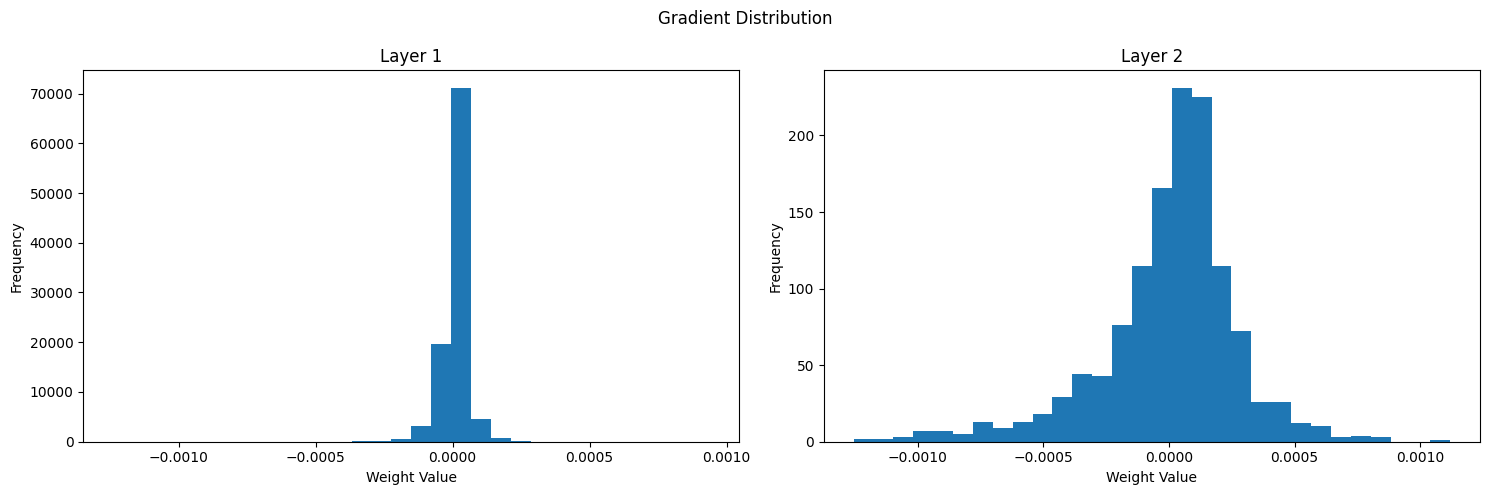

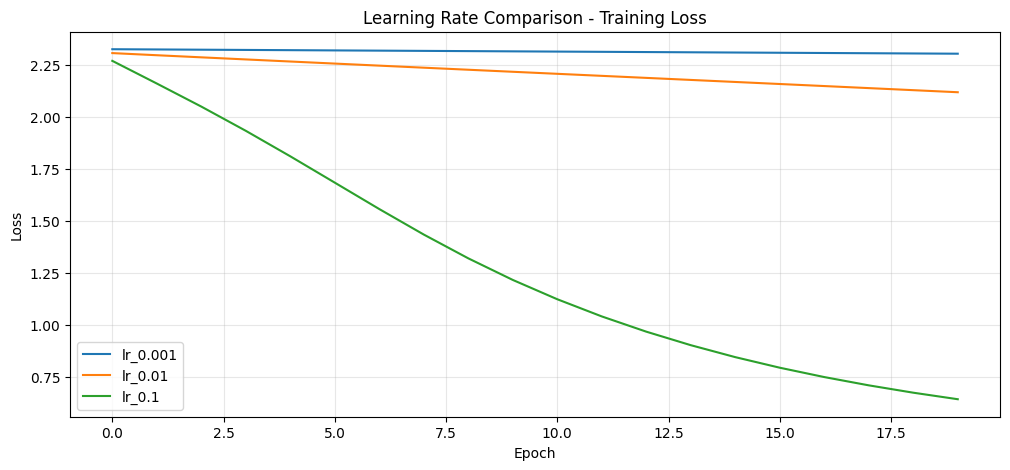

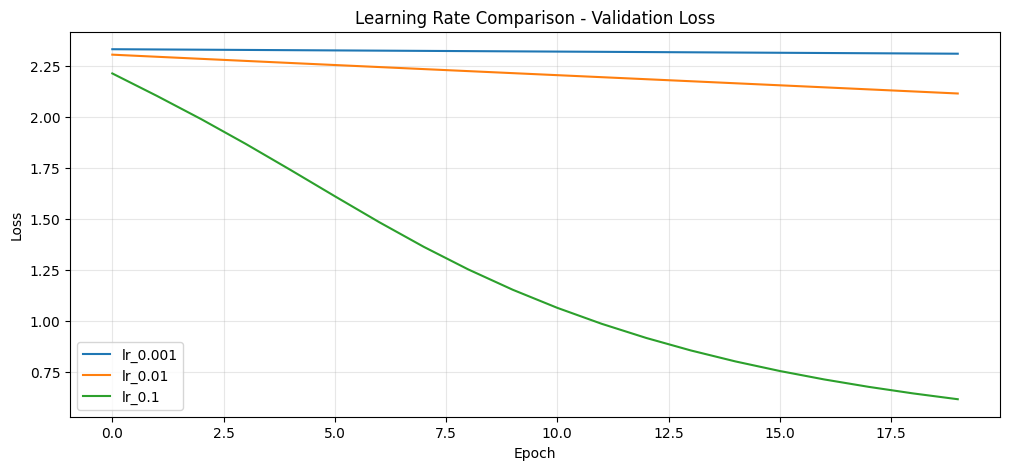

In [ ]:
# Different Learning Rates
learning_rates = [0.001, 0.01, 0.1]

fixed_width = 128
fixed_layer_sizes = [784, fixed_width, 10]

lr_models = {}
lr_histories = {}

print("\n--- Learning Rate Experiments ---")
for lr in learning_rates:
    name = f"lr_{lr}"
    
    print(f"\nTraining model with learning_rate={lr}")
    model = FFNN(
        layer_sizes=fixed_layer_sizes,
        activations=['relu', 'softmax'],
        loss='categorical_cross_entropy',
        weight_initializer='uniform'
    )
    
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        
        iterator = batch_iterator(X_train, y_train_one_hot, batch_size=batch_size)
        n_batches = int(np.ceil(len(X_train) / batch_size))
        
        for batch_idx, (X_batch, y_batch) in enumerate(tqdm(iterator, total=n_batches, 
                                                        desc=f'Epoch {epoch+1}/{epochs}')):
            # Forward and backward pass
            model.forward(X_batch)
            batch_loss = model.backward(y_batch)
            
            # Update weights
            model.update_weights(lr)
            
            # Accumulate loss
            epoch_loss += batch_loss * len(X_batch) / len(X_train)
        
        history['train_loss'].append(epoch_loss)
        
        val_pred = model.forward(X_test)
        val_loss = model.loss.compute(y_test_one_hot, val_pred)
        history['val_loss'].append(val_loss)
        
        print(f'Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.4f} - val_loss: {val_loss:.4f}')
    
    lr_models[name] = model
    lr_histories[name] = history
    
    # Evaluate model
    print(f"\nEvaluation for {name}:")
    evaluate_model(model, X_test, y_test, y_test_one_hot)

    has_nan_weights = any(np.isnan(w).any() for w in model.weights)
    has_nan_gradients = any(np.isnan(g).any() for g in model.weight_gradients)
    
    # Plot weight distribution
    print(f"\nWeight distribution for {name}:")
    # model.plot_weight()
    if has_nan_weights:
        print("cant plot weight distribution. nan values")
    else:
        model.plot_weight()
    
    # Plot gradient distribution
    print(f"\nGradient distribution for {name}:")
    # model.plot_gradient_distribution()
    if has_nan_gradients:
        print("cant plot weight distribution. nan values")
    else:
        model.plot_gradient_distribution()

# Plot training histories
plot_comparison(lr_histories, "Learning Rate Comparison - Training Loss", "train_loss")
plot_comparison(lr_histories, "Learning Rate Comparison - Validation Loss", "val_loss")

## Weight Initialization


--- Weight Initialization Experiments ---

Training model with initializer=zero


Epoch 1/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.3026 - val_loss: 2.3026


Epoch 2/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.3026 - val_loss: 2.3026


...

Epoch 18/20 - loss: 2.3024 - val_loss: 2.3025


Epoch 19/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 19/20 - loss: 2.3024 - val_loss: 2.3025


Epoch 20/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 20/20 - loss: 2.3024 - val_loss: 2.3025

Evaluation for init_zero:
Test accuracy: 0.1080


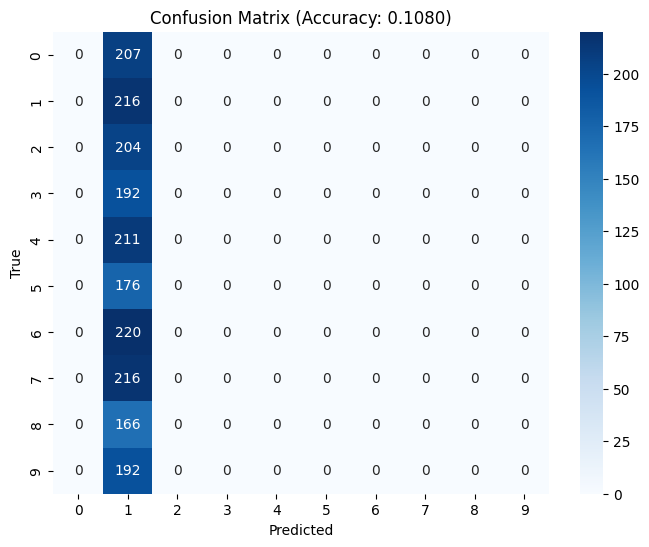


Weight distribution for init_zero:


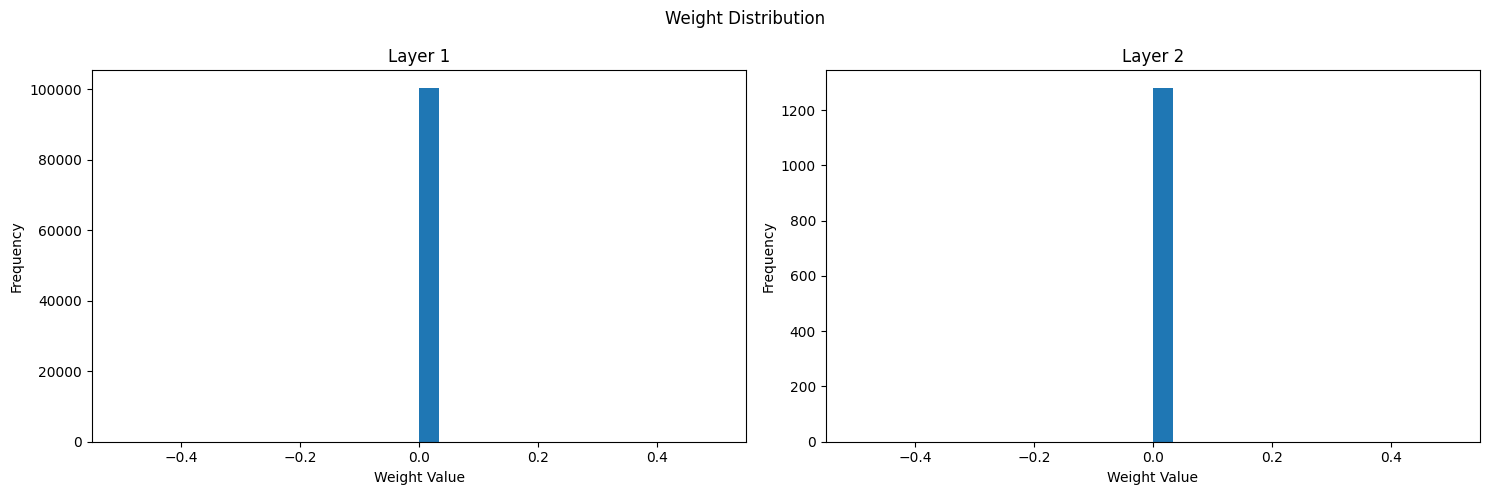


Gradient distribution for init_zero:


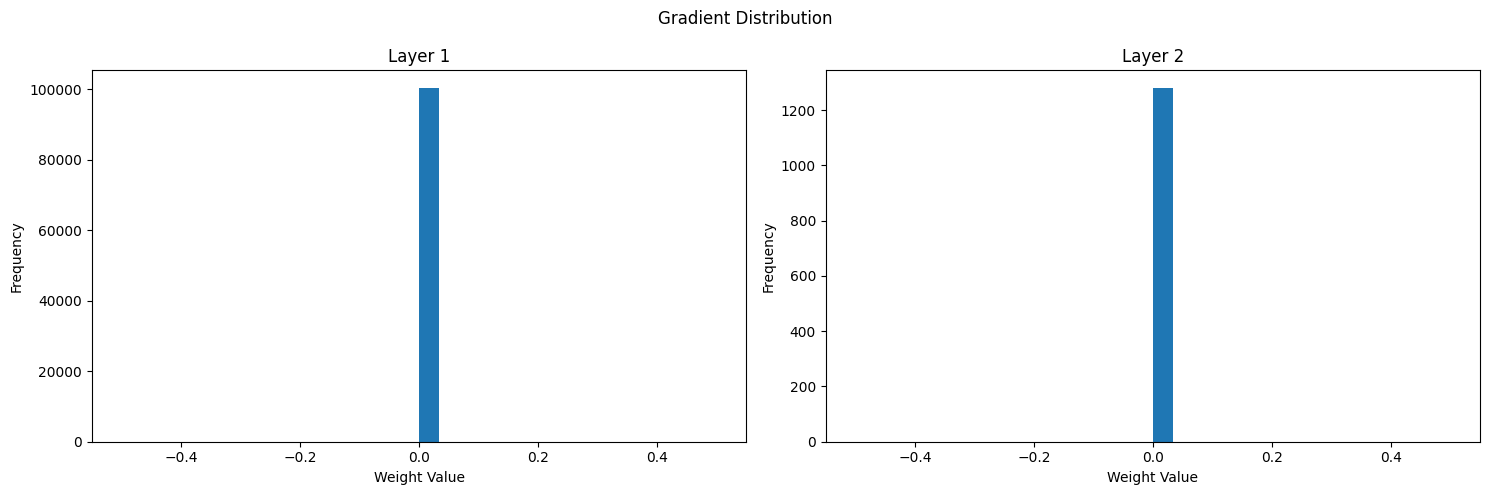


Training model with initializer=uniform


Epoch 1/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.2854 - val_loss: 2.2809


Epoch 2/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.2749 - val_loss: 2.2703


...

Epoch 18/20 - loss: 2.1108 - val_loss: 2.1044


Epoch 19/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 19/20 - loss: 2.1004 - val_loss: 2.0939


Epoch 20/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 20/20 - loss: 2.0900 - val_loss: 2.0834

Evaluation for init_uniform:
Test accuracy: 0.5370


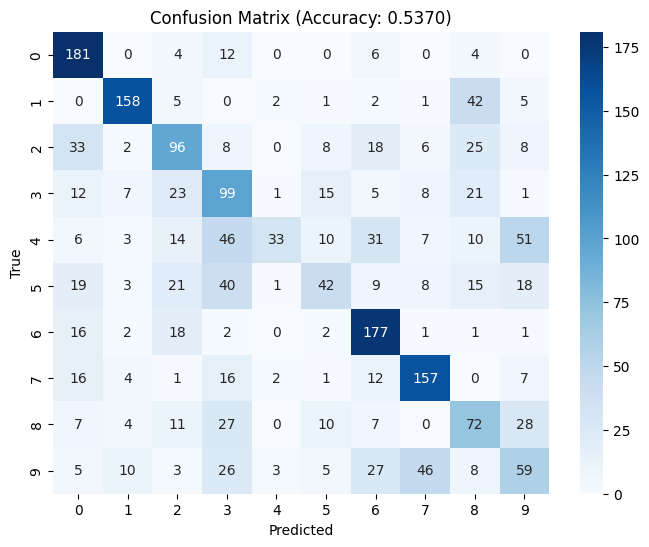


Weight distribution for init_uniform:


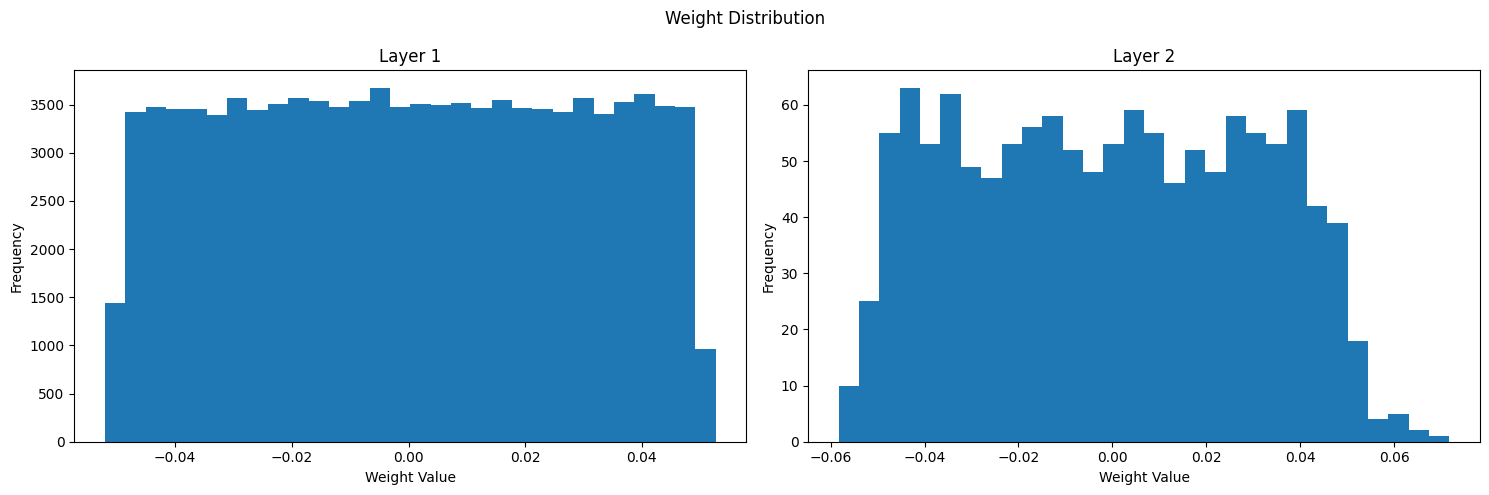


Gradient distribution for init_uniform:


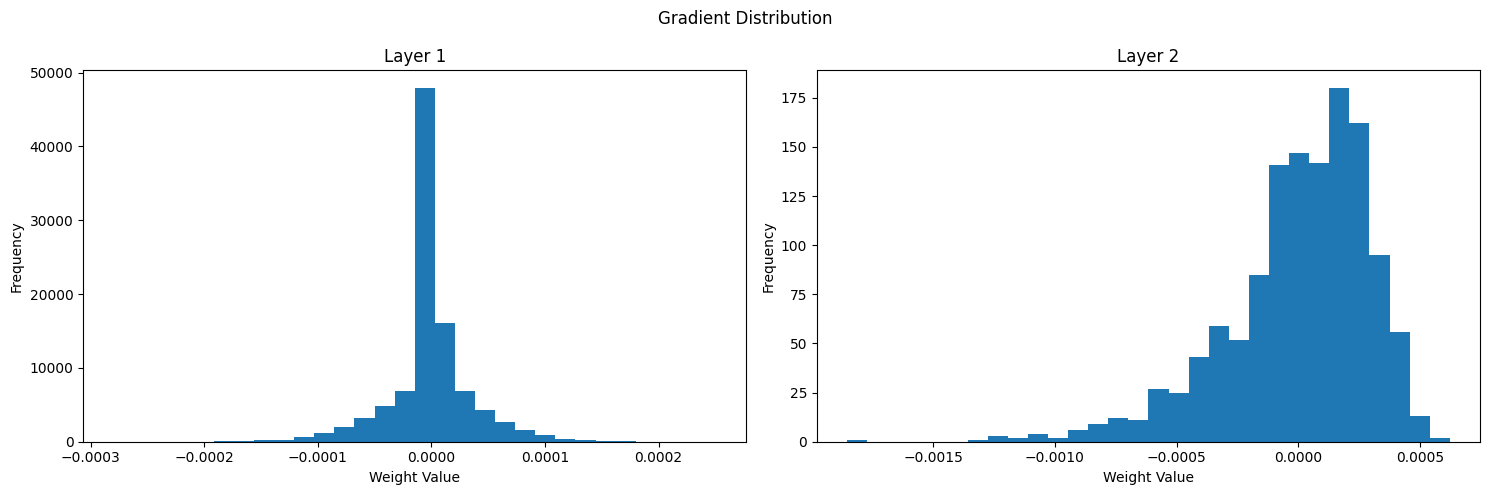


Training model with initializer=normal


Epoch 1/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.3028 - val_loss: 2.2963


Epoch 2/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.2681 - val_loss: 2.2621


...

Epoch 18/20 - loss: 1.8296 - val_loss: 1.8256


Epoch 19/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 19/20 - loss: 1.8069 - val_loss: 1.8029


Epoch 20/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 20/20 - loss: 1.7846 - val_loss: 1.7806

Evaluation for init_normal:
Test accuracy: 0.5490


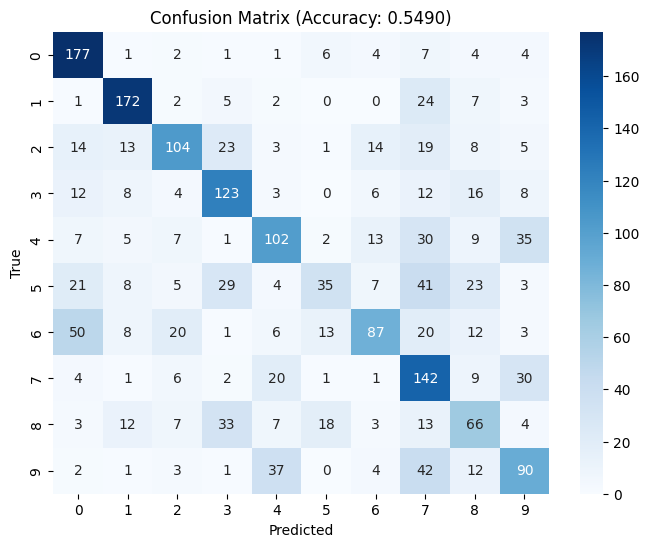


Weight distribution for init_normal:


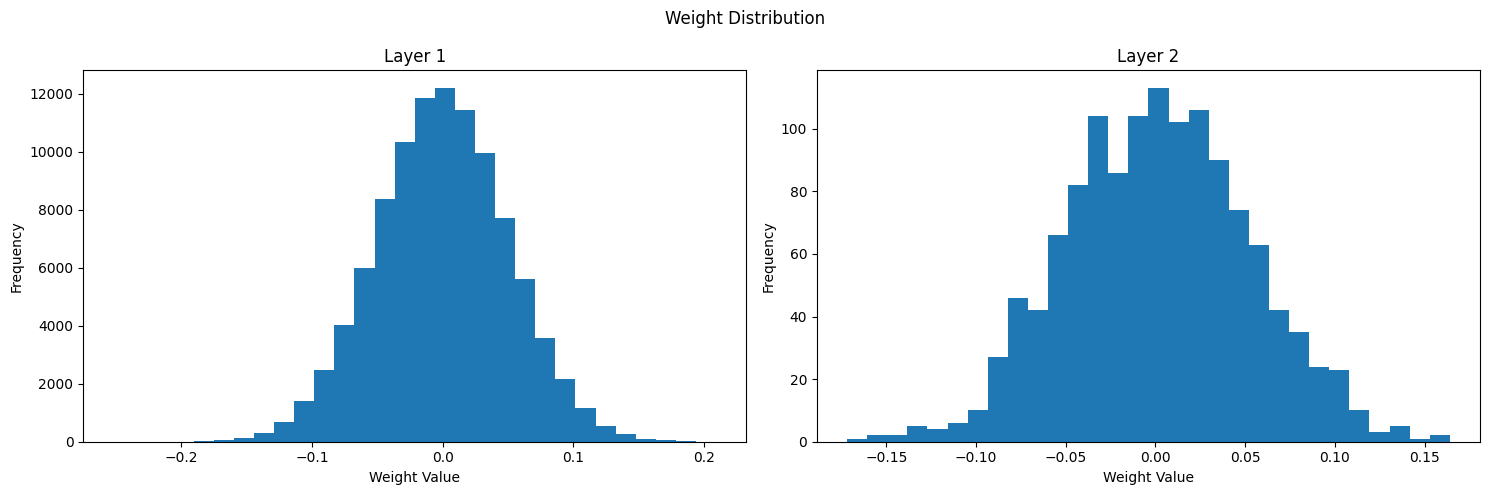


Gradient distribution for init_normal:


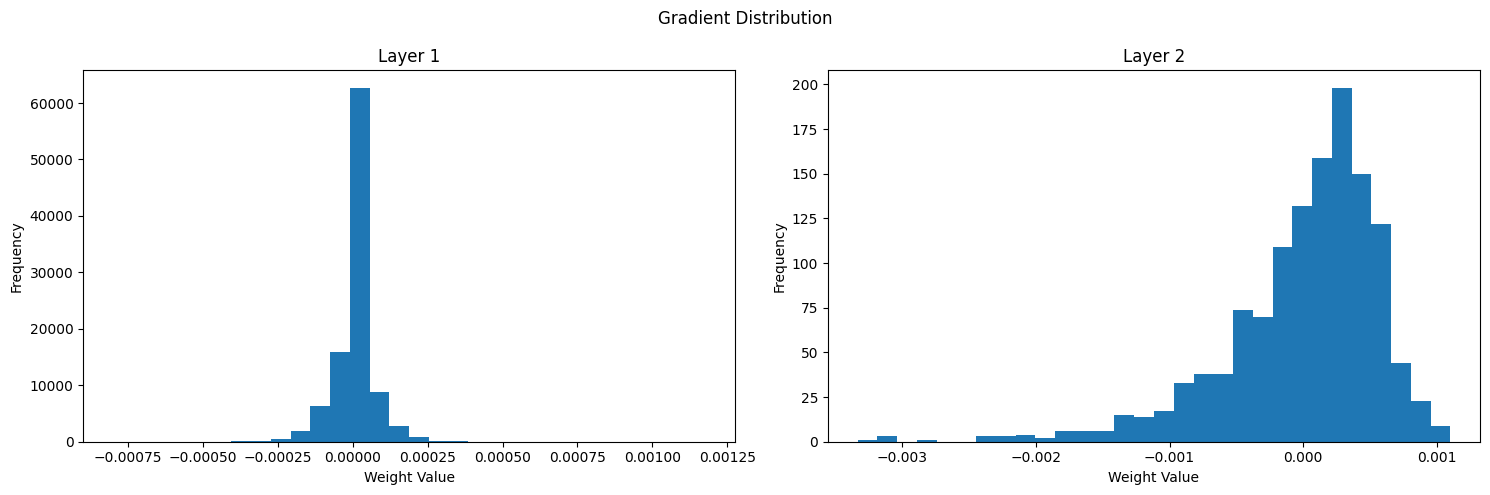


Training model with initializer=xavier


Epoch 1/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.5821 - val_loss: 2.4802


Epoch 2/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.4702 - val_loss: 2.3746


...

Epoch 18/20 - loss: 1.4540 - val_loss: 1.4143


Epoch 19/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 19/20 - loss: 1.4199 - val_loss: 1.3820


Epoch 20/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 20/20 - loss: 1.3878 - val_loss: 1.3516

Evaluation for init_xavier:
Test accuracy: 0.6305


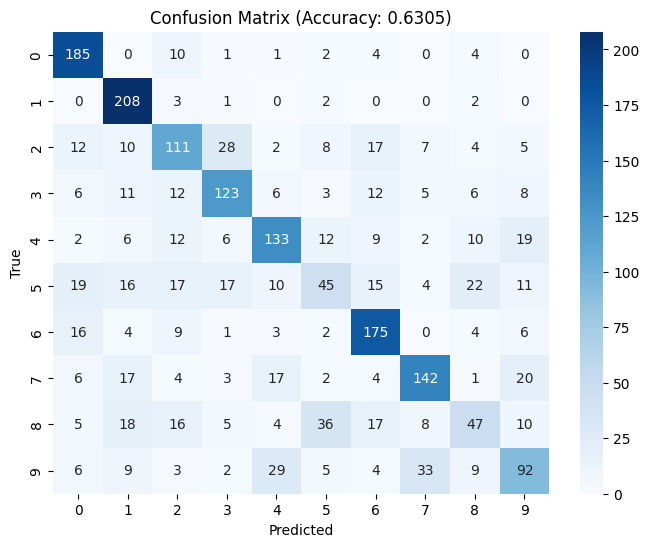


Weight distribution for init_xavier:


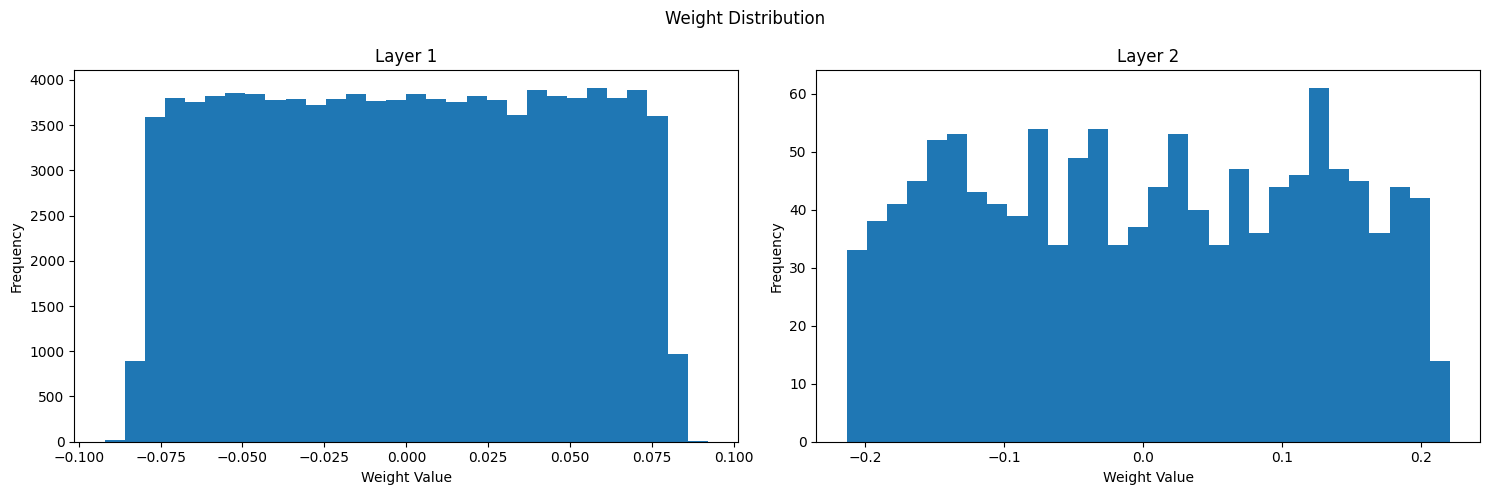


Gradient distribution for init_xavier:


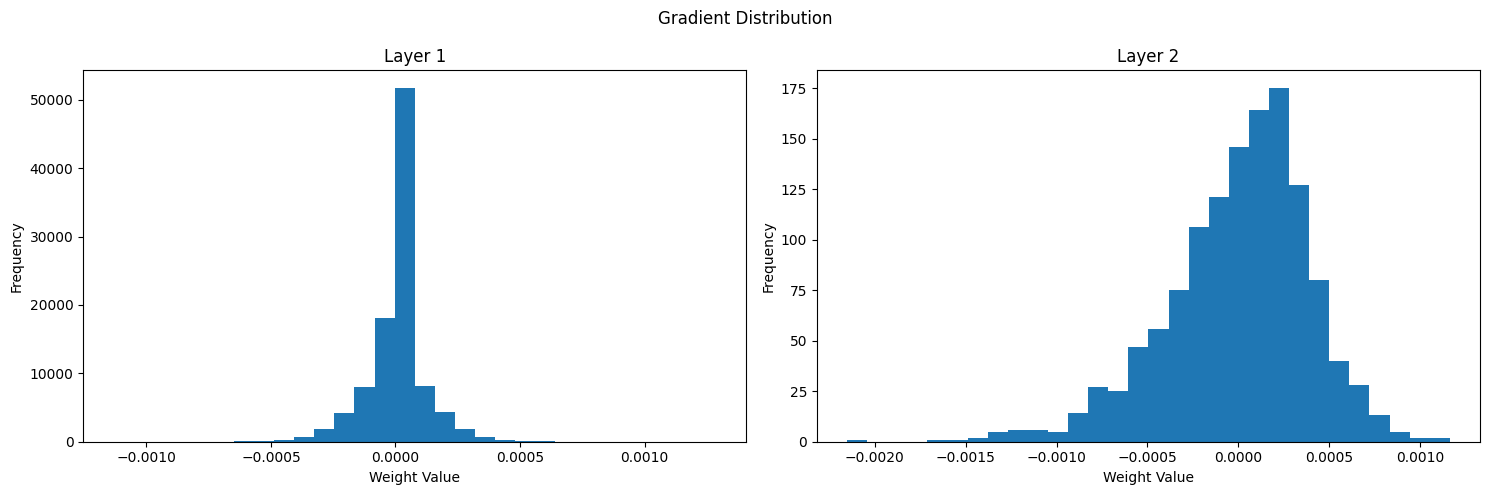


Training model with initializer=he


Epoch 1/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.5729 - val_loss: 2.5298


Epoch 2/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.4545 - val_loss: 2.4158


...

Epoch 18/20 - loss: 1.3781 - val_loss: 1.3685


Epoch 19/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 19/20 - loss: 1.3429 - val_loss: 1.3338


Epoch 20/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 20/20 - loss: 1.3099 - val_loss: 1.3013

Evaluation for init_he:
Test accuracy: 0.6520


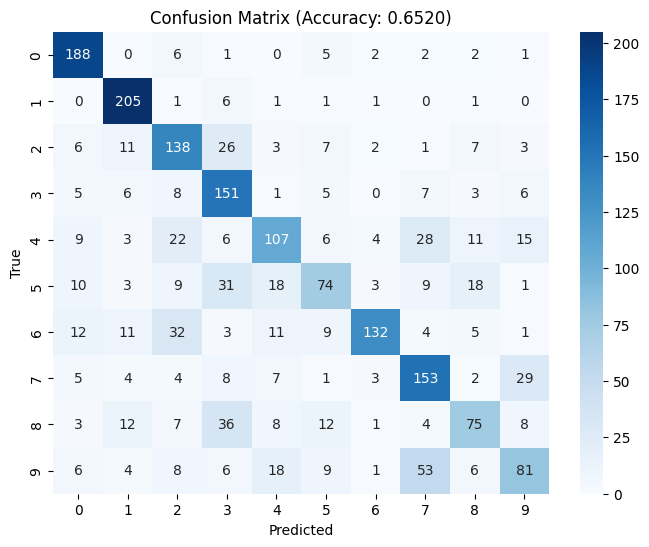


Weight distribution for init_he:


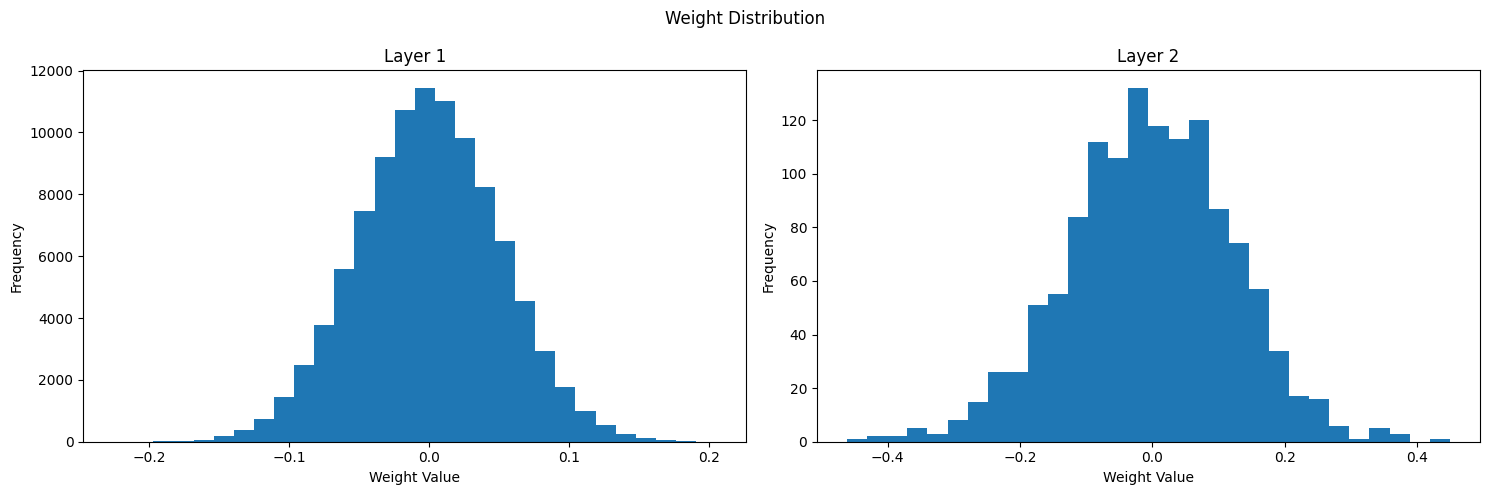


Gradient distribution for init_he:


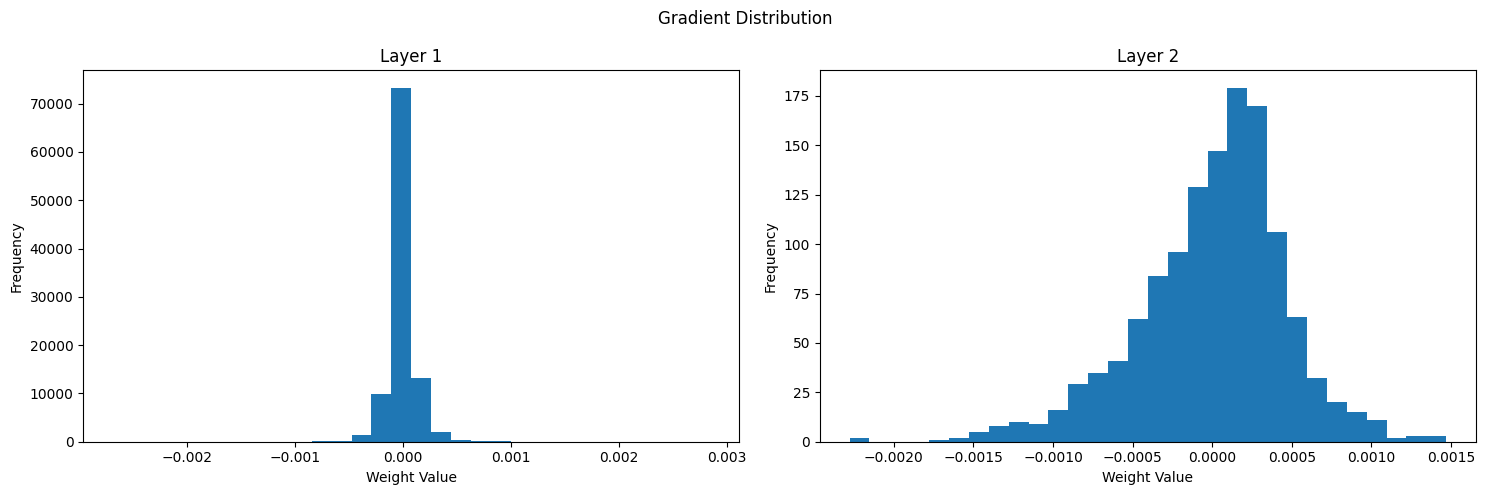

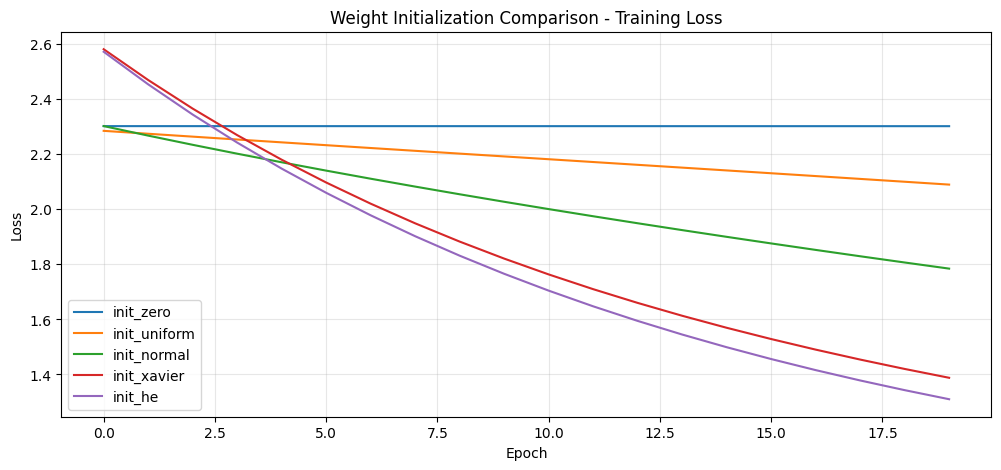

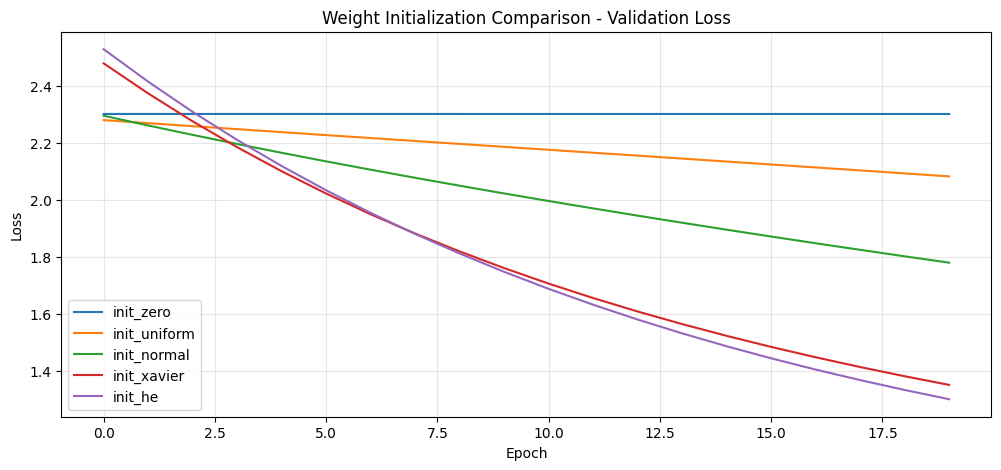

In [ ]:
initializers = [
    {'name': 'zero', 'params': {}},
    {'name': 'uniform', 'params': {'low': -0.05, 'high': 0.05}},
    {'name': 'normal', 'params': {'mean': 0, 'std': 0.05}},
    # Bonus initializers (masih tes tes)
    {'name': 'xavier', 'params': {}},
    {'name': 'he', 'params': {}}
]

fixed_width = 128
fixed_layer_sizes = [784, fixed_width, 10]
fixed_lr = 0.01

init_models = {}
init_histories = {}

print("\n--- Weight Initialization Experiments ---")
for init in initializers:
    name = f"init_{init['name']}"
    
    try:
        print(f"\nTraining model with initializer={init['name']}")
        model = FFNN(
            layer_sizes=fixed_layer_sizes,
            activations=['relu', 'softmax'],
            loss='categorical_cross_entropy',
            weight_initializer=init['name'],
            weight_init_params=init['params'],
            # use_rms_norm=True
        )
        
        history = {'train_loss': [], 'val_loss': []}
        
        for epoch in range(epochs):
            epoch_loss = 0.0
            
            iterator = batch_iterator(X_train, y_train_one_hot, batch_size=batch_size)
            n_batches = int(np.ceil(len(X_train) / batch_size))
            
            for batch_idx, (X_batch, y_batch) in enumerate(tqdm(iterator, total=n_batches, 
                                                            desc=f'Epoch {epoch+1}/{epochs}')):
                # Forward and backward pass
                model.forward(X_batch)
                batch_loss = model.backward(y_batch)
                
                # Update weights
                model.update_weights(fixed_lr)
                
                # Accumulate loss
                epoch_loss += batch_loss * len(X_batch) / len(X_train)
            
            history['train_loss'].append(epoch_loss)
            
            val_pred = model.forward(X_test)
            val_loss = model.loss.compute(y_test_one_hot, val_pred)
            history['val_loss'].append(val_loss)
            
            print(f'Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.4f} - val_loss: {val_loss:.4f}')
        
        init_models[name] = model
        init_histories[name] = history
        
        # Evaluate model
        print(f"\nEvaluation for {name}:")
        evaluate_model(model, X_test, y_test, y_test_one_hot)
    
        has_nan_weights = any(np.isnan(w).any() for w in model.weights)
        has_nan_gradients = any(np.isnan(g).any() for g in model.weight_gradients)
        
        # Plot weight distribution
        print(f"\nWeight distribution for {name}:")
        # model.plot_weight()
        if has_nan_weights:
            print("cant plot weight distribution. nan values")
        else:
            model.plot_weight()
        
        # Plot gradient distribution
        print(f"\nGradient distribution for {name}:")
        # model.plot_gradient_distribution()
        if has_nan_gradients:
            print("cant plot weight distribution. nan values")
        else:
            model.plot_gradient_distribution()
    
    except Exception as e:
        print(f"Error with initializer {init['name']}: {e}")

# Plot training histories for successful initializers
valid_initializers = init_histories.keys()
if valid_initializers:
    plot_comparison(init_histories, "Weight Initialization Comparison - Training Loss", "train_loss")
    plot_comparison(init_histories, "Weight Initialization Comparison - Validation Loss", "val_loss")

## Comparison


--- Sklearn Comparison ---

Training custom FFNN model


Epoch 1/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.4814 - val_loss: 2.1925


Epoch 2/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.0319 - val_loss: 1.8838


...

Epoch 19/20 - loss: 0.7057 - val_loss: 0.7040


Epoch 20/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 20/20 - loss: 0.6781 - val_loss: 0.6793

Evaluation for custom FFNN model:
Custom FFNN test accuracy: 0.8055

Training sklearn MLPClassifier
Iteration 1, loss = 0.60022312
Iteration 2, loss = 0.21552766
Iteration 3, loss = 0.14975266
Iteration 4, loss = 0.11204760
Iteration 5, loss = 0.08758810
Iteration 6, loss = 0.07075194
Iteration 7, loss = 0.05654122
Iteration 8, loss = 0.04670982
Iteration 9, loss = 0.03835652
Iteration 10, loss = 0.03271039
Iteration 11, loss = 0.02760567
Iteration 12, loss = 0.02399851
Iteration 13, loss = 0.02102648
Iteration 14, loss = 0.01840881
Iteration 15, loss = 0.01620390
Iteration 16, loss = 0.01450057
Iteration 17, loss = 0.01309660
Iteration 18, loss = 0.01179318
Iteration 19, loss = 0.01083677
Iteration 20, loss = 0.00996903


c:\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


Sklearn MLPClassifier test accuracy: 0.9450

Accuracy comparison:
Custom FFNN: 0.8055
Sklearn MLP: 0.9450
Agreement between models: 0.8210


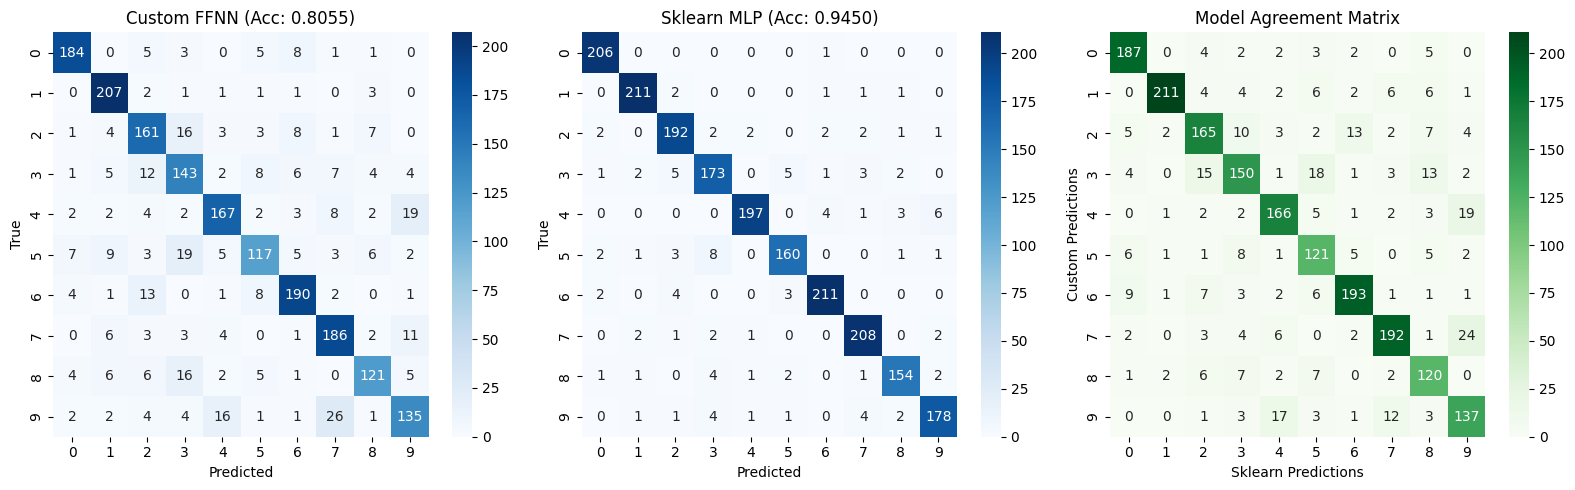

In [ ]:
fixed_width = 128
fixed_layer_sizes = [784, fixed_width, 10]
fixed_lr = 0.01
fixed_activation = 'relu'

# custom FFNN model
print("\n--- Sklearn Comparison ---")
print("\nTraining custom FFNN model")
custom_model = FFNN(
    layer_sizes=fixed_layer_sizes,
    activations=[fixed_activation, 'softmax'],
    loss='categorical_cross_entropy',
    weight_initializer='uniform',
    use_rms_norm=True
)

custom_history = {'train_loss': [], 'val_loss': []}

for epoch in range(epochs):
    epoch_loss = 0.0
    
    iterator = batch_iterator(X_train, y_train_one_hot, batch_size=batch_size)
    n_batches = int(np.ceil(len(X_train) / batch_size))
    
    for batch_idx, (X_batch, y_batch) in enumerate(tqdm(iterator, total=n_batches, 
                                                    desc=f'Epoch {epoch+1}/{epochs}')):
        # Forward and backward pass
        custom_model.forward(X_batch)
        batch_loss = custom_model.backward(y_batch)
        
        # Update weights
        custom_model.update_weights(fixed_lr)
        
        # Accumulate loss
        epoch_loss += batch_loss * len(X_batch) / len(X_train)
    
    custom_history['train_loss'].append(epoch_loss)
    
    val_pred = custom_model.forward(X_test)
    val_loss = custom_model.loss.compute(y_test_one_hot, val_pred)
    custom_history['val_loss'].append(val_loss)
    
    print(f'Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.4f} - val_loss: {val_loss:.4f}')

# Evaluate custom model
print("\nEvaluation for custom FFNN model:")
custom_pred = custom_model.predict(X_test)
custom_pred_class = np.argmax(custom_pred, axis=1)
custom_acc = accuracy_score(y_test, custom_pred_class)
print(f"Custom FFNN test accuracy: {custom_acc:.4f}")

# sklearn model
print("\nTraining sklearn MLPClassifier")
sklearn_model = MLPClassifier(
    hidden_layer_sizes=(fixed_width,),
    activation=fixed_activation,
    solver='sgd',
    alpha=0.0001,  # L2
    batch_size=batch_size,
    learning_rate_init=fixed_lr,
    max_iter=epochs,
    shuffle=True,
    random_state=42,
    verbose=True
)

sklearn_model.fit(X_train, y_train)

# Evaluate sklearn model
sklearn_pred = sklearn_model.predict(X_test)
sklearn_acc = accuracy_score(y_test, sklearn_pred)
print(f"Sklearn MLPClassifier test accuracy: {sklearn_acc:.4f}")

# Compare models
print(f"\nAccuracy comparison:")
print(f"Custom FFNN: {custom_acc:.4f}")
print(f"Sklearn MLP: {sklearn_acc:.4f}")

# Compare predictions
agreement = np.mean(custom_pred_class == sklearn_pred)
print(f"Agreement between models: {agreement:.4f}")

plt.figure(figsize=(16, 5))

# Custom FFNN confusion matrix
plt.subplot(1, 3, 1)
custom_cm = confusion_matrix(y_test, custom_pred_class)
sns.heatmap(custom_cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Custom FFNN (Acc: {custom_acc:.4f})')
plt.xlabel('Predicted')
plt.ylabel('True')

# Sklearn model confusion matrix
plt.subplot(1, 3, 2)
sklearn_cm = confusion_matrix(y_test, sklearn_pred)
sns.heatmap(sklearn_cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Sklearn MLP (Acc: {sklearn_acc:.4f})')
plt.xlabel('Predicted')
plt.ylabel('True')

# Plot agreement
plt.subplot(1, 3, 3)
agreement_cm = confusion_matrix(custom_pred_class, sklearn_pred)
sns.heatmap(agreement_cm, annot=True, fmt='d', cmap='Greens')
plt.title('Model Agreement Matrix')
plt.xlabel('Sklearn Predictions')
plt.ylabel('Custom Predictions')

plt.tight_layout()
plt.show()

## Regularizers


--- Regularization Experiments ---

Training model with regularizer=None


Epoch 1/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.3070 - val_loss: 2.2990


Epoch 2/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.2954 - val_loss: 2.2872


...

Epoch 18/20 - loss: 2.1377 - val_loss: 2.1270


Epoch 19/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 19/20 - loss: 2.1287 - val_loss: 2.1179


Epoch 20/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 20/20 - loss: 2.1198 - val_loss: 2.1088

Evaluation for reg_None:
Test accuracy: 0.4790


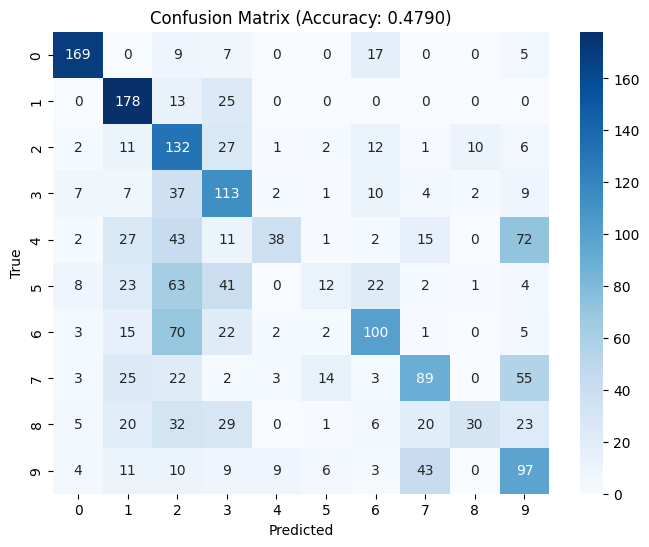


Weight distribution for reg_None:


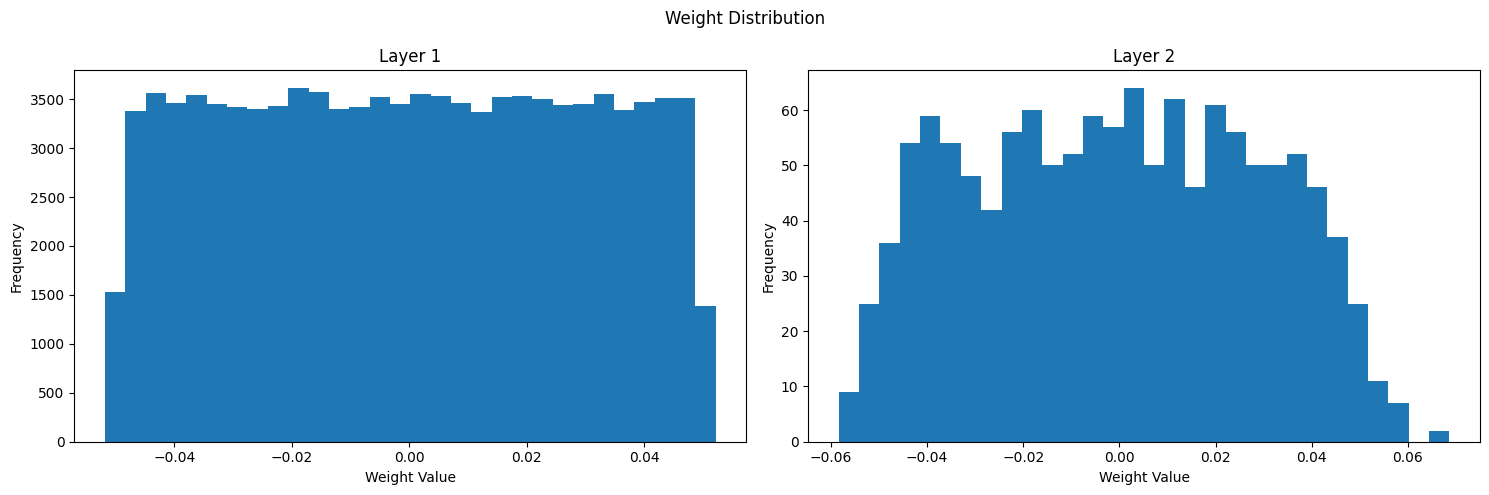


Gradient distribution for reg_None:


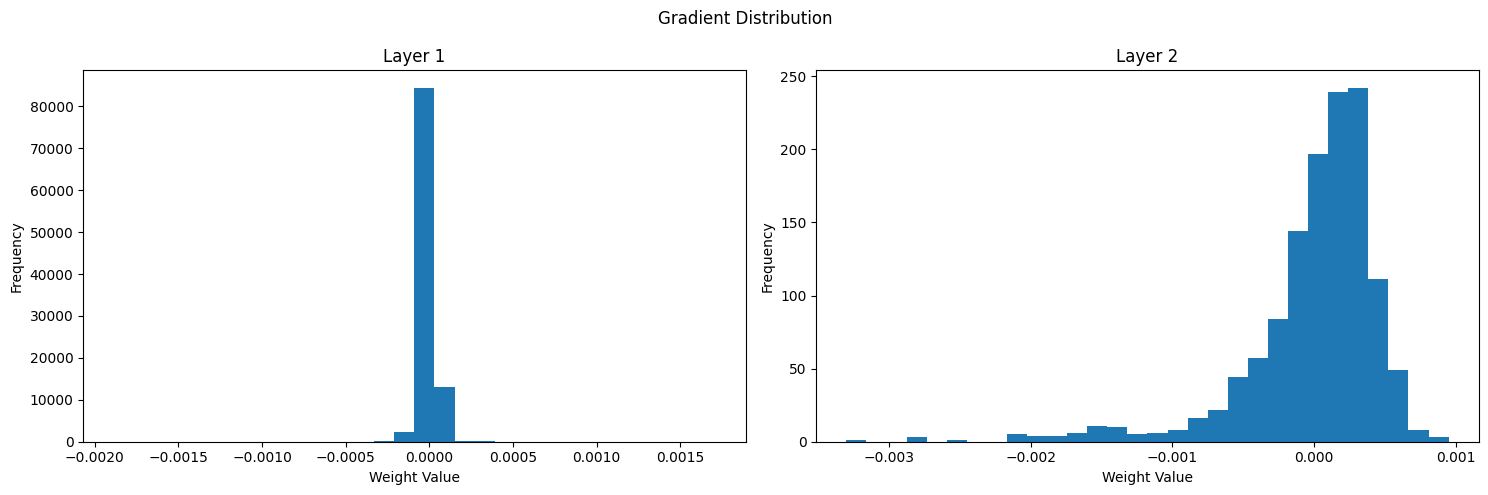


Training model with regularizer=L1


Epoch 1/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1/20 - loss: 21.8823 - val_loss: 2.3144


Epoch 2/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2/20 - loss: 12.3490 - val_loss: 2.3029


...

Epoch 18/20 - loss: 2.3532 - val_loss: 2.3025


Epoch 19/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 19/20 - loss: 2.3532 - val_loss: 2.3025


Epoch 20/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 20/20 - loss: 2.3532 - val_loss: 2.3025

Evaluation for reg_L1:
Test accuracy: 0.1080


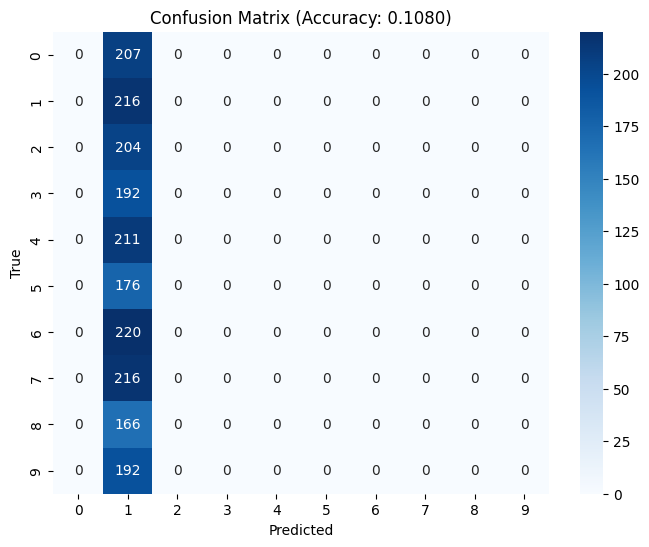


Weight distribution for reg_L1:


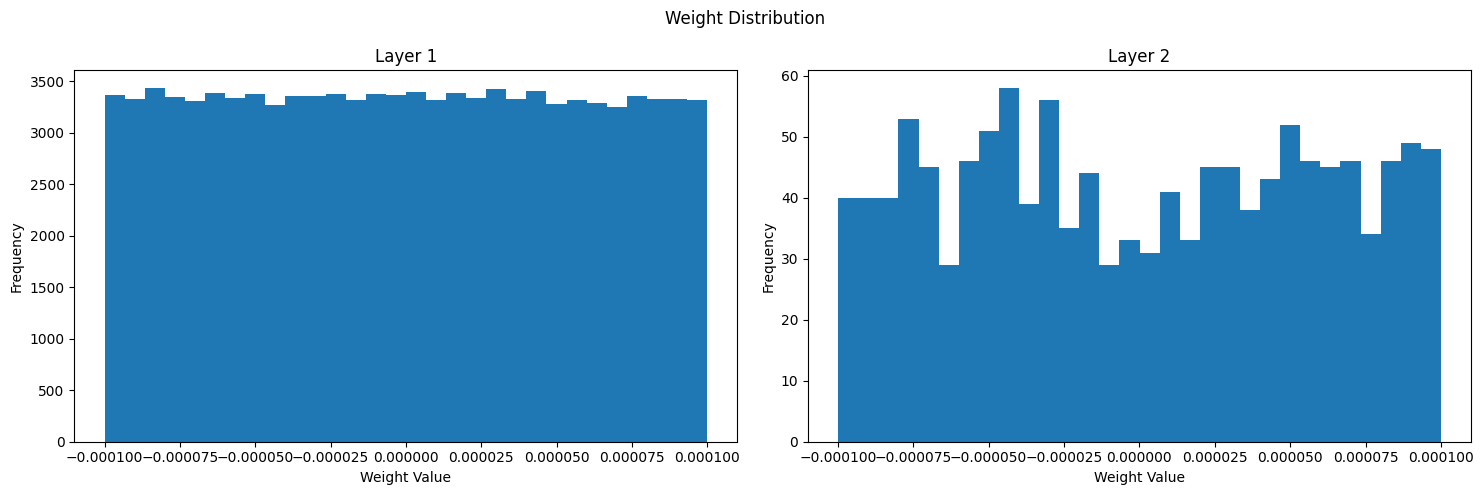


Gradient distribution for reg_L1:


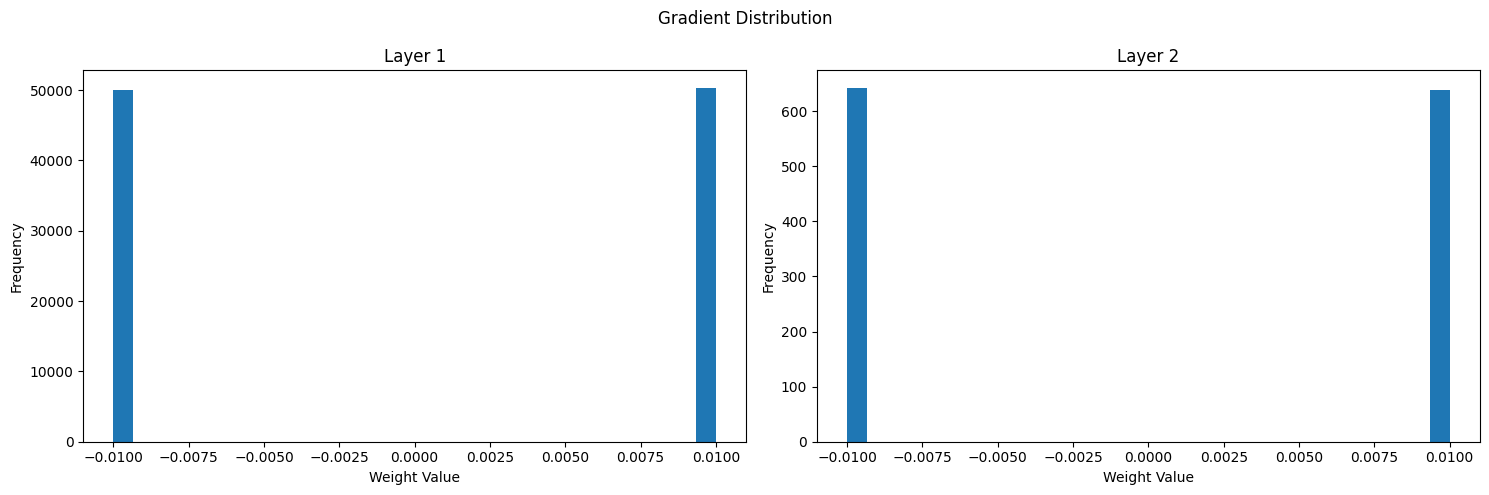


Training model with regularizer=L2


Epoch 1/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1/20 - loss: 2.7305 - val_loss: 2.3048


Epoch 2/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2/20 - loss: 2.7073 - val_loss: 2.2926


...

Epoch 18/20 - loss: 2.4626 - val_loss: 2.1852


Epoch 19/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 19/20 - loss: 2.4521 - val_loss: 2.1816


Epoch 20/20:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 20/20 - loss: 2.4421 - val_loss: 2.1782

Evaluation for reg_L2:
Test accuracy: 0.5185


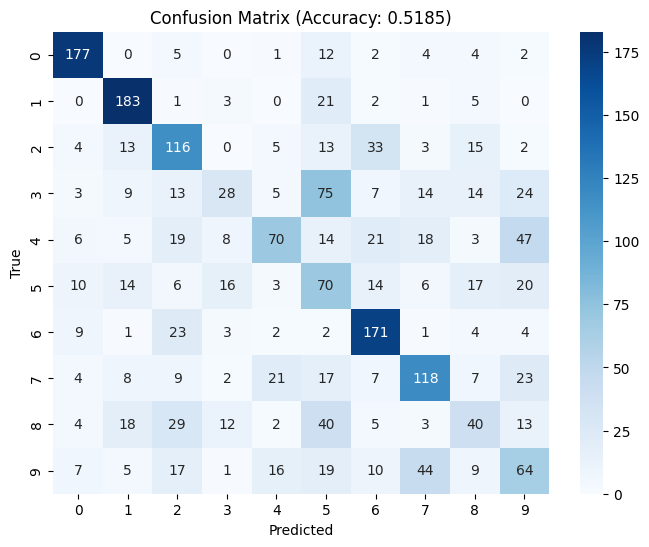


Weight distribution for reg_L2:


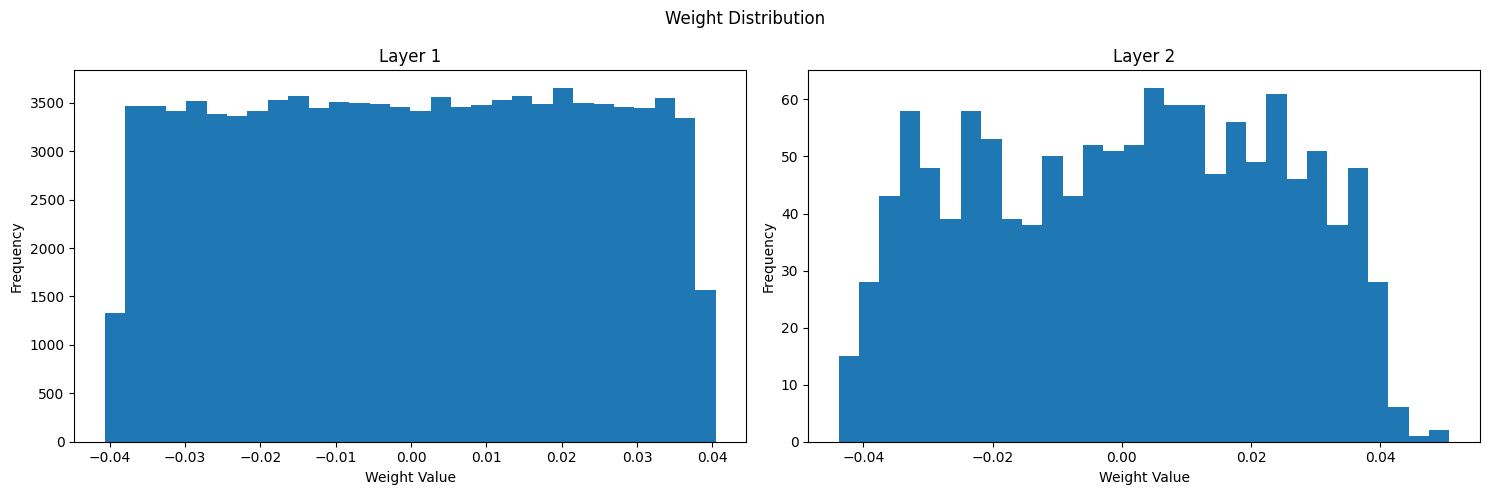


Gradient distribution for reg_L2:


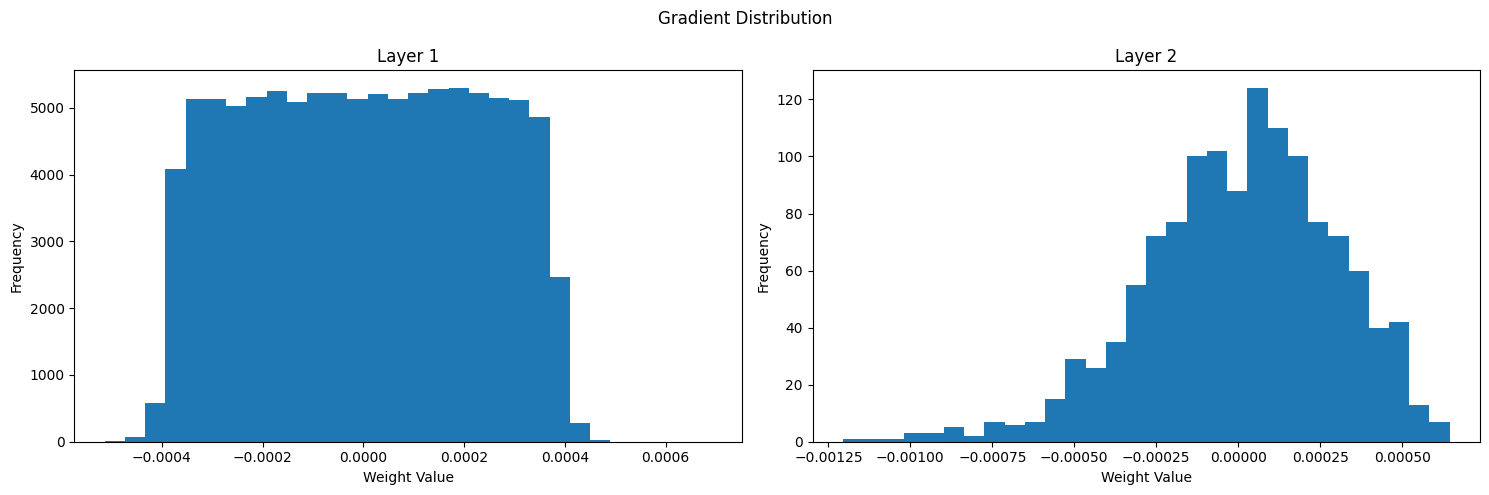

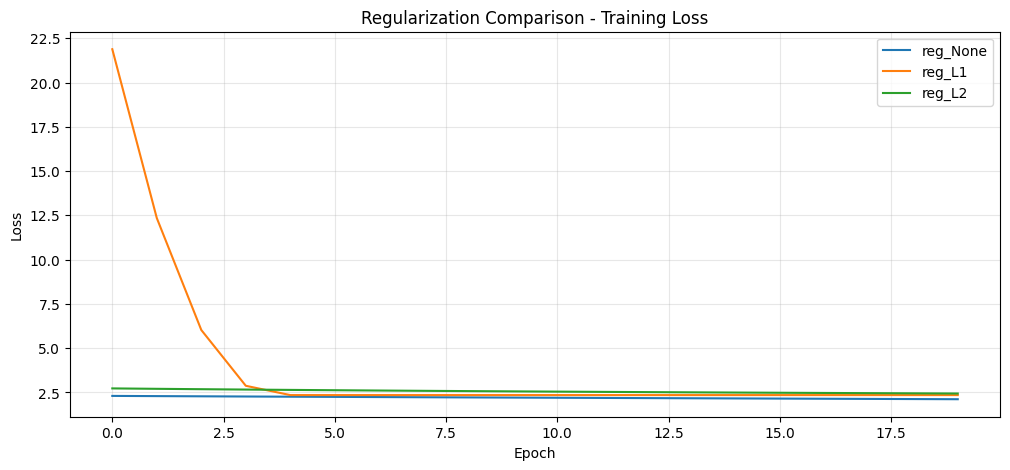

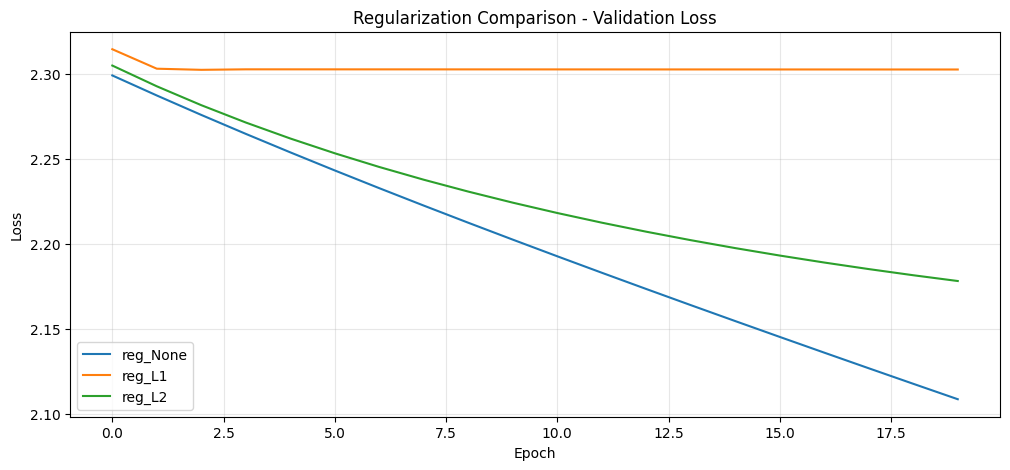

In [ ]:
# Define regularizers to test
regularizers = [
    {'name': 'None', 'regularizer': None},
    {'name': 'L1', 'regularizer': 'l1'},
    {'name': 'L2', 'regularizer': 'l2'}
]

# Fixed network architecture and training parameters
fixed_width = 128
fixed_layer_sizes = [784, fixed_width, 10]
fixed_lr = 0.01

# Dictionary to store models and their histories
reg_models = {}
reg_histories = {}

# Run experiments
print("\n--- Regularization Experiments ---")
for reg in regularizers:
    name = f"reg_{reg['name']}"
    
    # Create and train model
    print(f"\nTraining model with regularizer={reg['name']}")
    model = FFNN(
        layer_sizes=fixed_layer_sizes,
        activations=['relu', 'softmax'],
        loss='categorical_cross_entropy',
        weight_initializer='uniform',
        regularizer=reg['regularizer']
    )
    
    # Train model with progress bar
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        
        # Create mini-batches
        iterator = batch_iterator(X_train, y_train_one_hot, batch_size=batch_size)
        n_batches = int(np.ceil(len(X_train) / batch_size))
        
        # Mini-batch training with progress bar
        for batch_idx, (X_batch, y_batch) in enumerate(tqdm(iterator, total=n_batches, 
                                                        desc=f'Epoch {epoch+1}/{epochs}')):
            # Forward and backward pass
            model.forward(X_batch)
            batch_loss = model.backward(y_batch)
            
            # Update weights
            model.update_weights(fixed_lr)
            
            # Accumulate loss
            epoch_loss += batch_loss * len(X_batch) / len(X_train)
        
        # Record training loss
        history['train_loss'].append(epoch_loss)
        
        # Compute validation loss
        val_pred = model.forward(X_test)
        val_loss = model.loss.compute(y_test_one_hot, val_pred)
        history['val_loss'].append(val_loss)
        
        print(f'Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.4f} - val_loss: {val_loss:.4f}')
    
    # Store model and history
    reg_models[name] = model
    reg_histories[name] = history
    
    # Evaluate model
    print(f"\nEvaluation for {name}:")
    evaluate_model(model, X_test, y_test, y_test_one_hot)
    
    # Plot weight distribution
    print(f"\nWeight distribution for {name}:")
    model.plot_weight()
    
    # Plot gradient distribution
    print(f"\nGradient distribution for {name}:")
    model.plot_gradient_distribution()

# Plot training histories
plot_comparison(reg_histories, "Regularization Comparison - Training Loss", "train_loss")
plot_comparison(reg_histories, "Regularization Comparison - Validation Loss", "val_loss")

## RMSNorm


--- Normalization Experiments ---

Training model with normalization=None


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 243.85it/s]


Epoch 1/20 - 2.62s - loss: 2.5932 - val_loss: 2.3165 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 281.27it/s]


Epoch 2/20 - 2.27s - loss: 2.1053 - val_loss: 1.9326 - lr: 0.009800


...

Epoch 18/20 - 2.27s - loss: 0.6967 - val_loss: 0.7142 - lr: 0.007093


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 286.30it/s]


Epoch 19/20 - 2.23s - loss: 0.6796 - val_loss: 0.6981 - lr: 0.006951


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 284.74it/s]


Epoch 20/20 - 2.24s - loss: 0.6641 - val_loss: 0.6836 - lr: 0.006812

Evaluation for norm_None:
Test accuracy: 0.8204


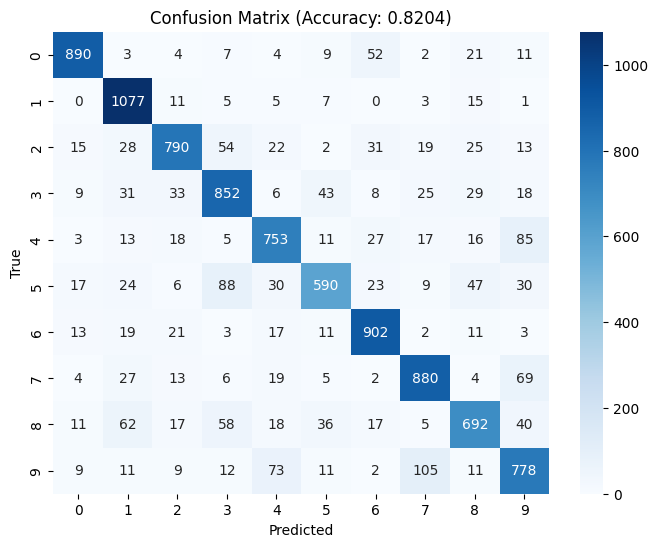


Weight distribution for norm_None:


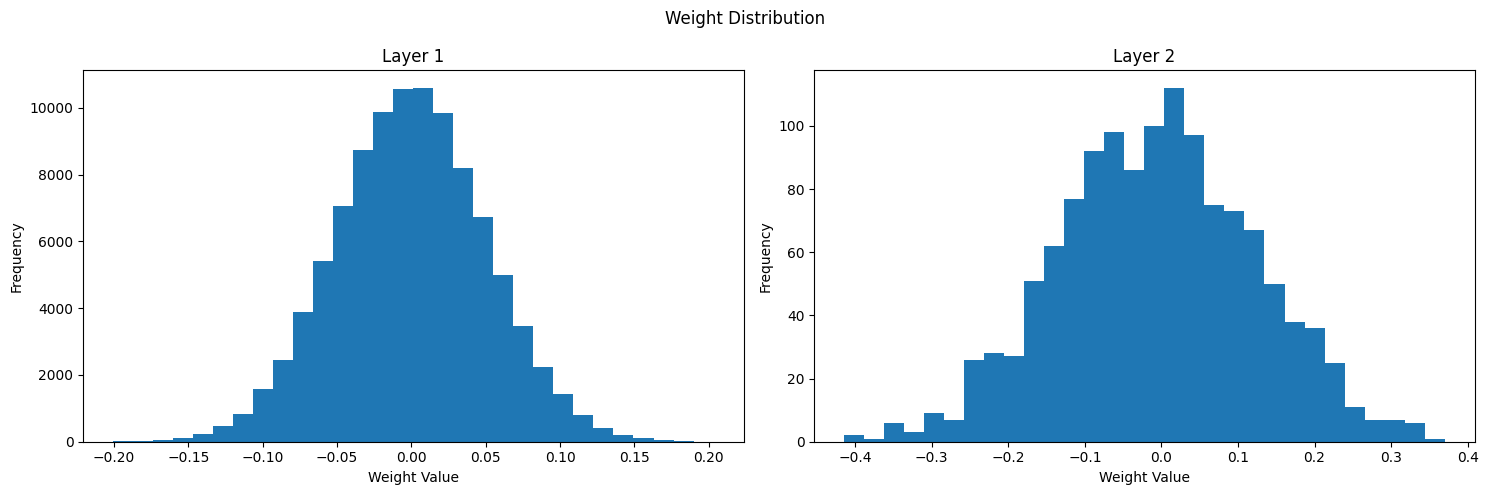


Gradient distribution for norm_None:


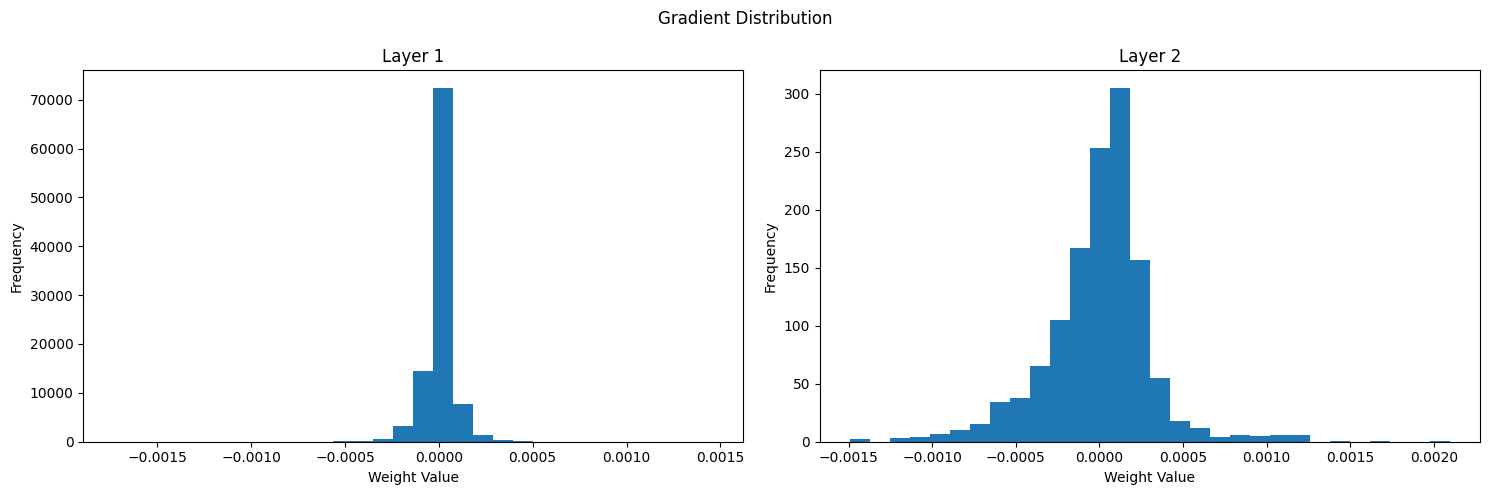


Training model with normalization=RMSNorm


Epoch 1/20: 100%|██████████| 625/625 [00:02<00:00, 257.73it/s]


Epoch 1/20 - 2.49s - loss: 2.4165 - val_loss: 2.2041 - lr: 0.010000


Epoch 2/20: 100%|██████████| 625/625 [00:02<00:00, 271.62it/s]


Epoch 2/20 - 2.37s - loss: 2.0969 - val_loss: 2.0057 - lr: 0.009800


...

Epoch 18/20 - 2.34s - loss: 0.6865 - val_loss: 0.6957 - lr: 0.007093


Epoch 19/20: 100%|██████████| 625/625 [00:02<00:00, 269.75it/s]


Epoch 19/20 - 2.37s - loss: 0.6586 - val_loss: 0.6662 - lr: 0.006951


Epoch 20/20: 100%|██████████| 625/625 [00:02<00:00, 277.53it/s]


Epoch 20/20 - 2.31s - loss: 0.6359 - val_loss: 0.6508 - lr: 0.006812

Evaluation for norm_RMSNorm:
Test accuracy: 0.7891


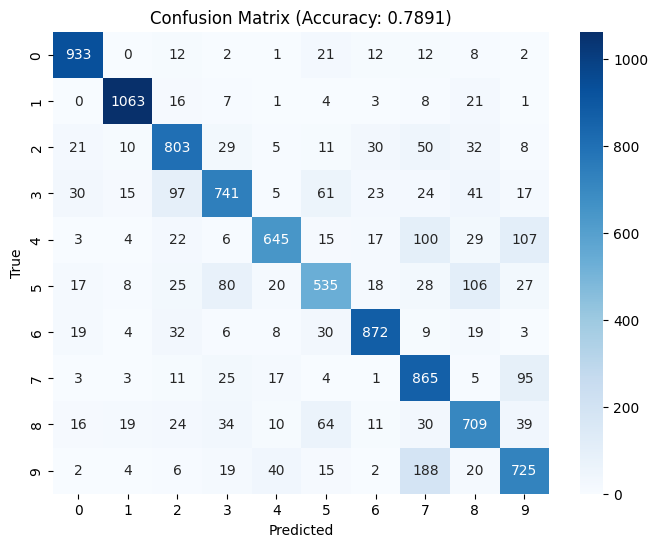


Weight distribution for norm_RMSNorm:


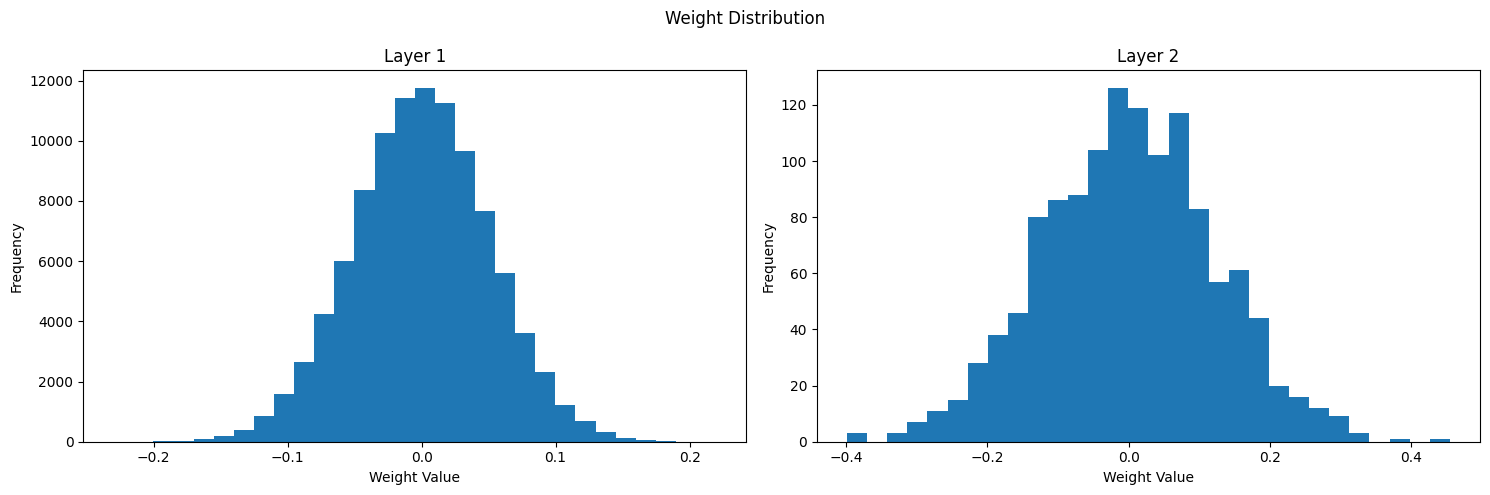


Gradient distribution for norm_RMSNorm:


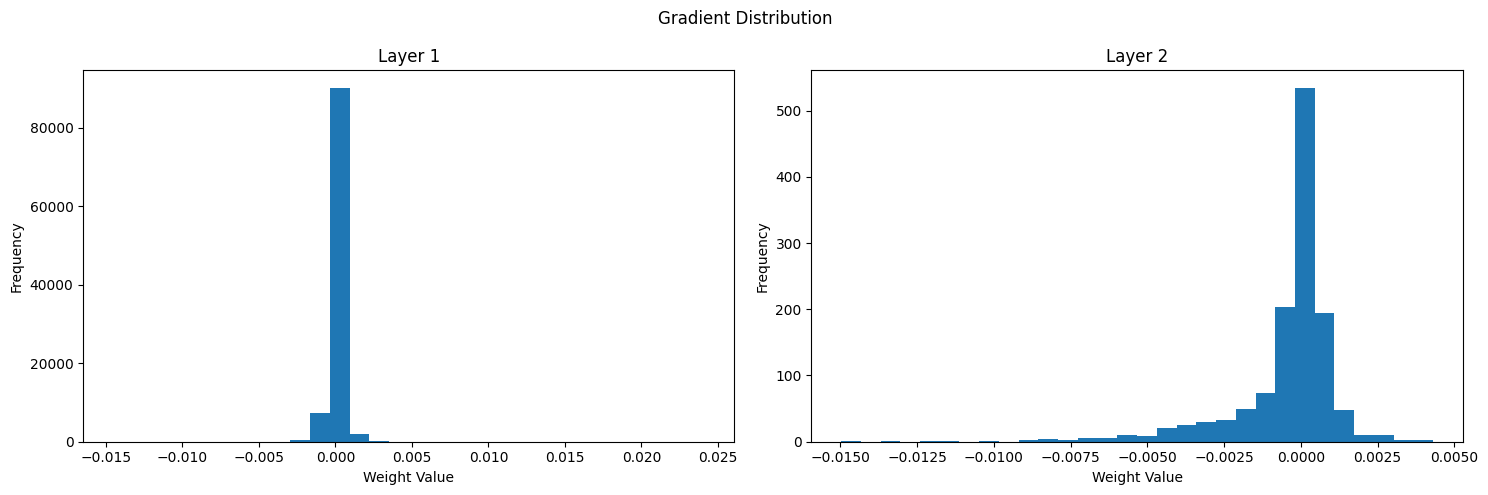

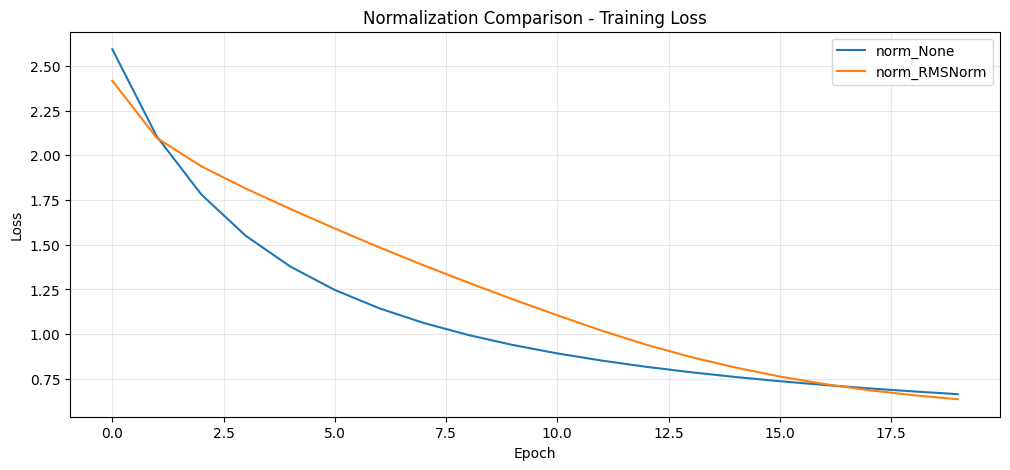

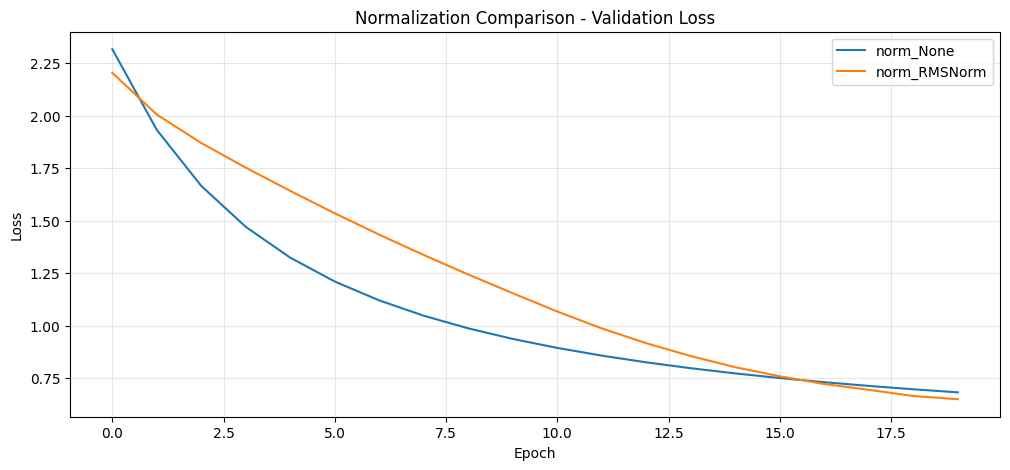

In [ ]:
# normalization options
normalizations = [
    {'name': 'None', 'use_rms_norm': False},
    {'name': 'RMSNorm', 'use_rms_norm': True}
]

fixed_width = 128
fixed_layer_sizes = [784, fixed_width, fixed_width, fixed_width, fixed_width 10]
fixed_lr = 0.01

norm_models = {}
norm_histories = {}

print("\n--- Normalization Experiments ---")
for norm in normalizations:
    name = f"norm_{norm['name']}"
    
    print(f"\nTraining model with normalization={norm['name']}")
    model = FFNN(
        layer_sizes=fixed_layer_sizes,
        activations=['relu', 'relu', 'relu', 'relu', 'softmax'],
        loss='categorical_cross_entropy',
        weight_initializer='he',
        use_rms_norm=norm['use_rms_norm']
    )
    
    history = model.fit(
        X_train, 
        y_train_one_hot,
        batch_size=batch_size,
        learning_rate=fixed_lr,
        epochs=epochs,
        verbose=1,
        validation_data=(X_test, y_test_one_hot),
        gradient_clip=1.0,
        learning_rate_decay=0.98,
        early_stopping_patience=5
    )
    
    # Store model and history
    norm_models[name] = model
    norm_histories[name] = history
    
    # Evaluate model
    print(f"\nEvaluation for {name}:")
    evaluate_model(model, X_test, y_test, y_test_one_hot)
    
    # Check for NaN values before plotting
    has_nan_weights = any(np.isnan(w).any() for w in model.weights)
    has_nan_gradients = any(np.isnan(g).any() for g in model.weight_gradients)
    
    # Plot weight distribution
    print(f"\nWeight distribution for {name}:")
    if has_nan_weights:
        print("can't plot weight distribution due to nan values")
    else:
        model.plot_weight()
    
    # Plot gradient distribution
    print(f"\nGradient distribution for {name}:")
    if has_nan_gradients:
        print("can't plot gradient distribution due to nan values")
    else:
        model.plot_gradient_distribution()

# Plot training histories
plot_comparison(norm_histories, "Normalization Comparison - Training Loss", "train_loss")
plot_comparison(norm_histories, "Normalization Comparison - Validation Loss", "val_loss")

# 1. **Depth and Width**: BAGUS OR NO
# 2. **Activation Functions**: BAGUS OR NO
# 3. **Learning Rate**: BAGUS OR NO
# 4. **Weight Initialization**: BAGUS OR NO
# 5. **Comparison with sklearn**: BAGUS OR NO
# 6. **Regularization (Bonus)**: BAGUS OR NO
# 7. **RMSNorm (Bonus)**: BAGUS OR NO